# Hospital Performance, Patient Flow & Readmission Analytics
### *Hospital Analytics & Readmission Intelligence*

**AICTE | IBM SkillsBuild — Data Analytics with AI Academic Internship 2026 | BharatCares**

---

**Dataset:** India Hospital Readmission & Discharge relational dataset (2015–2024) — 5 linked tables (`admissions`, `patients`, `diagnoses`, `billing`, `hospitals`)
**Grain:** one row of `admissions` = one hospital admission episode.
**Primary ML target:** `readmitted_30d` — did the patient return to hospital within 30 days of this discharge?

This notebook follows the full analytics chain:

> **Raw Data → Information → Insights → Risks / Opportunities → Recommended Actions**

A prior reference notebook (`predicting-readmission-auc-0-79-shap-eda.ipynb`) on a similar dataset was reviewed for ideas (EDA angles, feature-engineering patterns, SHAP workflow). Its structure has been **reorganised and rebuilt from scratch against the schema actually present in the files provided**, with an explicit leakage audit and a corrected model-training population (Section 15) that the reference notebook did not perform — the reference notebook, for example, did not notice that patients who died in hospital cannot, by definition, be readmitted, which silently biases both EDA rates and model training if left in.


## 1. Problem Statement

Hospitals accumulate large volumes of admission, clinical, financial and diagnosis data but rarely convert it into a connected view of **performance, patient flow, cost, and clinical risk**. Unplanned 30-day readmissions are a widely used quality-of-care indicator — costly, disruptive for patients, and in many cases at least partially preventable through better discharge planning and follow-up targeting.

This project builds an end-to-end analytics pipeline across 33 hospitals and 120,000 admissions to quantify performance, patient flow, and cost; identify factors associated with 30-day readmission; build an explainable predictive model usable at the point of discharge; and translate every finding into a concrete recommendation.

## 2. Objectives

| # | Objective |
|---|---|
| 1 | Hospital performance analysis (volume, LOS, tier, teaching status, bed utilisation) |
| 2 | Patient analytics (demographics, socioeconomic status, clinical burden) |
| 3 | Patient flow analytics (admission/discharge patterns, procedures, trends over time) |
| 4 | Financial analytics (billing, subsidy, out-of-pocket burden) |
| 5 | Readmission analytics (30-day & 7-day, across every relevant cut) |
| 6 | Predictive analytics — a 30-day readmission risk model with SHAP explainability |

## 3. Business Questions

- Which hospitals/tiers carry disproportionate patient load relative to bed capacity?
- Which patient segments (age, comorbidity, prior-admission history, BPL status) show materially higher readmission rates?
- Where does out-of-pocket financial burden concentrate?
- Which admission/discharge-time signals could a hospital use to flag a patient for a follow-up programme *before they leave*?
- What does a clinically-sensible, leakage-free readmission risk model look like, and how much can it realistically explain (SHAP)?


## 4. Dataset Description

Five relational CSV files were provided. Schemas below were derived by direct inspection — nothing is assumed.

| File | Rows | Grain | Primary key | Foreign key(s) |
|---|---|---|---|---|
| `admissions.csv` | 120,000 | one admission episode | `admission_id` | `patient_id` -> patients, `hospital_id` -> hospitals |
| `patients.csv` | 86,400 | one patient | `patient_id` | - |
| `diagnoses.csv` | 271,341 | one diagnosis line on an admission (avg ~2.26/admission) | `diag_id` | `admission_id` -> admissions |
| `billing.csv` | 120,000 | one bill per admission | `bill_id` | `admission_id` -> admissions |
| `hospitals.csv` | 33 | one hospital | `hospital_id` | - |

**Column-level data dictionary (as found in the files):**

*admissions.csv* — `admission_id`, `patient_id`, `admit_date`, `discharge_date`, `los_days` (length of stay), `admit_type` (Elective / OPD / Emergency), `ward_type` (General / ICU / HDU / NICU), `hospital_id`, `discharge_type` (Recovered / LAMA / Referred / Expired), `num_procedures`, `charlson_index` (comorbidity severity score), `hba1c`, `creatinine`, `haemoglobin`, `systolic_bp` (admission-time labs/vitals), `readmitted_30d`, `readmitted_7d` (binary outcome flags).

*patients.csv* — `patient_id`, `age`, `gender` (F/M/Other), `state`, `bpl_card` (Below-Poverty-Line card, bool), `insurance_type` (Private / ESI / Ayushman / missing), `comorbidity_count`, `prev_admissions` (prior admission count before this record).

*diagnoses.csv* — `diag_id`, `admission_id`, `icd10_code`, `diag_desc`, `diag_rank` (1 = primary diagnosis, 2+ = secondary), `diag_category`.

*billing.csv* — `bill_id`, `admission_id`, `total_cost_inr`, `govt_subsidy_inr`, `out_of_pocket_inr`, `cost_category` (dominant cost line: Lab / Room / Procedure / Pharmacy).

*hospitals.csv* — `hospital_id`, `name`, `state`, `tier` (tier1 private / tier2 government-teaching / tier3 district), `beds`, `teaching` (bool).

## 5. Dataset Architecture

```
patients (86,400) --1:N-- admissions (120,000) --1:N-- diagnoses (271,341)
                               |  |
                               |  +--1:1-- billing (120,000)
                               +--N:1-- hospitals (33)
```

`admissions` is the fact table. `patients` and `hospitals` are dimension tables (many admissions can belong to the same patient / hospital — 120,000 admissions come from only 64,873 unique patients, i.e. ~28.5% of patients in this table have more than one admission). `diagnoses` is a one-to-many child of `admissions` and **must not be joined directly onto the admission grain** without aggregating first, or every admission row would be duplicated once per diagnosis line. `billing` is one-to-one with `admissions`.


---
## 6. Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                              accuracy_score, precision_score, recall_score, f1_score,
                              classification_report)
import xgboost as xgb
import shap

pd.set_option('display.max_columns', 60)
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#FAFAF8',
    'axes.grid': True, 'grid.alpha': 0.25, 'axes.edgecolor': '#333333',
    'font.size': 10.5,
})
TEAL, CORAL, PURPLE, NAVY, GOLD, GREY = '#1B8A8A', '#E4572E', '#6C5CE7', '#264653', '#E9B44C', '#8D99AE'
PALETTE = [TEAL, CORAL, PURPLE, GOLD, NAVY, GREY]
sns.set_palette(PALETTE)

RANDOM_STATE = 42
print('Libraries loaded.')

Libraries loaded.


---
## 7. Load Dataset

In [2]:
from pathlib import Path

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'

adm  = pd.read_csv(DATA_DIR / 'admissions.csv', parse_dates=['admit_date', 'discharge_date'])
pat  = pd.read_csv(DATA_DIR / 'patients.csv')
diag = pd.read_csv(DATA_DIR / 'diagnoses.csv')
bill = pd.read_csv(DATA_DIR / 'billing.csv')
hosp = pd.read_csv(DATA_DIR / 'hospitals.csv')


In [3]:
display(adm.head(3))
display(pat.head(3))
display(diag.head(3))
display(bill.head(3))
display(hosp.head(3))

,admission_id,patient_id,admit_date,discharge_date,los_days,admit_type,ward_type,hospital_id,discharge_type,num_procedures,charlson_index,hba1c,creatinine,haemoglobin,systolic_bp,readmitted_30d,readmitted_7d
0,bcb311d6-0808-498f-8ae1-11abe1fbc08e,6960d399-8398-4db4-9a90-0b329b81bc2b,2024-01-23,2024-01-27,4,Elective,General,b22e7b51-2ea6-4611-a8e5-d3d24ec779d8,Recovered,0,0,6.3,0.86,16.2,157,0,0
1,996ac6db-a192-46a0-b536-503a1c57994b,ec1999d4-f097-4881-91a5-6f9b1f8dac78,2019-11-18,2019-11-19,1,OPD,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,0,5.2,1.23,13.1,156,0,0
2,cc4849fa-b740-487b-beda-3086a18273c0,ed56abac-a0ba-44db-a816-b5da4183b9b5,2019-11-22,2019-11-27,5,Emergency,General,eae7c9ec-65c8-4d48-92f3-7da7b3e2b227,Recovered,0,2,5.6,0.67,10.9,130,1,0


,patient_id,age,gender,state,bpl_card,insurance_type,comorbidity_count,prev_admissions
0,2b179f89-9af7-45cf-86b4-3e01a47a3b7b,36,F,Telangana,False,Private,0,0
1,ecaeb9f3-d263-4712-b9b6-3312af5626ca,56,F,Uttar Pradesh,False,ESI,0,0
2,0160a5b6-877e-41e6-b84a-a2a51b367a36,67,F,Telangana,False,ESI,3,0


,diag_id,admission_id,icd10_code,diag_desc,diag_rank,diag_category
0,3b448b98-6b78-4c7c-94c1-f832581c5052,bcb311d6-0808-498f-8ae1-11abe1fbc08e,E87,Metabolic / electrolyte disorder,1,Endocrine
1,137c0404-f1b6-4aca-95f5-2217812a6975,996ac6db-a192-46a0-b536-503a1c57994b,J45,Asthma,1,Respiratory
2,4bfb76a1-12ed-4cbd-b905-34d4bf3196f0,cc4849fa-b740-487b-beda-3086a18273c0,G40,Epilepsy,1,Neurological


,bill_id,admission_id,total_cost_inr,govt_subsidy_inr,out_of_pocket_inr,cost_category
0,68e19242-4126-4a7a-afa2-9e6035cdcffa,bcb311d6-0808-498f-8ae1-11abe1fbc08e,18492,16630,1862,Lab
1,b740202e-1d7a-45b4-9575-21b35e219e37,996ac6db-a192-46a0-b536-503a1c57994b,1001,0,1001,Lab
2,f60fecaa-e769-42ea-bee8-58198bdd1208,cc4849fa-b740-487b-beda-3086a18273c0,59696,48650,11046,Room


,hospital_id,name,state,tier,beds,teaching
0,df0f948a-2202-459a-ba6f-7ffd7dedcc18,Government General Hospital Maharashtra,Maharashtra,tier2,314,True
1,3d59f4a6-ce9c-4945-8f1f-5929f09a7836,Government General Hospital Uttar Pradesh,Uttar Pradesh,tier2,481,True
2,aac12881-4dea-42f3-bf32-8add9d5eee49,Government General Hospital Tamil Nadu,Tamil Nadu,tier2,428,True


---
## 8. Data Quality Audit

Checking missing values, duplicates, key uniqueness, date validity, impossible numeric values and join integrity — on the actual files, before any cleaning or assumption.

In [4]:
print('MISSING VALUES\n' + '-'*40)
for name, df in [('admissions', adm), ('patients', pat), ('diagnoses', diag), ('billing', bill), ('hospitals', hosp)]:
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    if len(miss):
        print(f'\n{name}:')
        print((miss.to_frame('n_missing').assign(pct=lambda d: (d.n_missing/len(df)*100).round(2))))
    else:
        print(f'\n{name}: no missing values')

MISSING VALUES
----------------------------------------

admissions: no missing values

patients:
                n_missing    pct
insurance_type      24715  28.61

diagnoses: no missing values

billing: no missing values

hospitals: no missing values


In [5]:
print('DUPLICATE ROWS / DUPLICATE KEYS\n' + '-'*40)
print('admissions duplicate rows:', adm.duplicated().sum(), '| duplicate admission_id:', adm.admission_id.duplicated().sum())
print('patients duplicate rows:  ', pat.duplicated().sum(), '| duplicate patient_id:  ', pat.patient_id.duplicated().sum())
print('diagnoses duplicate rows: ', diag.duplicated().sum(), '| duplicate diag_id:     ', diag.diag_id.duplicated().sum())
print('billing duplicate rows:   ', bill.duplicated().sum(), '| duplicate bill_id:     ', bill.bill_id.duplicated().sum())
print('hospitals duplicate rows: ', hosp.duplicated().sum(), '| duplicate hospital_id: ', hosp.hospital_id.duplicated().sum())

DUPLICATE ROWS / DUPLICATE KEYS
----------------------------------------
admissions duplicate rows: 0 | duplicate admission_id: 0
patients duplicate rows:   0 | duplicate patient_id:   0


diagnoses duplicate rows:  0 | duplicate diag_id:      0
billing duplicate rows:    0 | duplicate bill_id:      0
hospitals duplicate rows:  0 | duplicate hospital_id:  0


In [6]:
print('RELATIONAL / JOIN INTEGRITY\n' + '-'*40)
print('admissions.patient_id  not found in patients :', (~adm.patient_id.isin(pat.patient_id)).sum())
print('admissions.hospital_id not found in hospitals:', (~adm.hospital_id.isin(hosp.hospital_id)).sum())
print('billing.admission_id   not found in admissions:', (~bill.admission_id.isin(adm.admission_id)).sum())
print('diagnoses.admission_id not found in admissions:', (~diag.admission_id.isin(adm.admission_id)).sum())
print()
print('admissions rows                :', len(adm))
print('unique patients referenced     :', adm.patient_id.nunique(), f'({adm.patient_id.nunique()/len(pat)*100:.1f}% of the patient table)')
print('billing rows per admission_id  :', bill.groupby('admission_id').size().unique())
print('diagnoses rows per admission_id: min', diag.groupby('admission_id').size().min(),
      '/ max', diag.groupby('admission_id').size().max(),
      '/ mean %.2f' % diag.groupby('admission_id').size().mean())

RELATIONAL / JOIN INTEGRITY
----------------------------------------
admissions.patient_id  not found in patients : 0
admissions.hospital_id not found in hospitals: 0
billing.admission_id   not found in admissions: 0
diagnoses.admission_id not found in admissions: 0

admissions rows                : 120000
unique patients referenced     : 64873 (75.1% of the patient table)


billing rows per admission_id  : [1]


diagnoses rows per admission_id: min 1 / max 4 / mean 2.26


In [7]:
print('DATE VALIDITY\n' + '-'*40)
print('admit_date range    :', adm.admit_date.min().date(), '->', adm.admit_date.max().date())
print('discharge before admit (impossible):', (adm.discharge_date < adm.admit_date).sum())

print('\nIMPOSSIBLE / OUT-OF-RANGE NUMERIC VALUES\n' + '-'*40)
checks = {
    'los_days <= 0'              : (adm.los_days <= 0).sum(),
    'num_procedures < 0'         : (adm.num_procedures < 0).sum(),
    'charlson_index < 0'         : (adm.charlson_index < 0).sum(),
    'systolic_bp outside 60-260' : (~adm.systolic_bp.between(60, 260)).sum(),
    'age < 0 or > 110 (patients)': (~pat.age.between(0, 110)).sum(),
    'comorbidity_count < 0'      : (pat.comorbidity_count < 0).sum(),
    'prev_admissions < 0'        : (pat.prev_admissions < 0).sum(),
    'total_cost_inr <= 0'        : (bill.total_cost_inr <= 0).sum(),
    'out_of_pocket > total_cost' : (bill.out_of_pocket_inr > bill.total_cost_inr).sum(),
    'beds <= 0 (hospitals)'      : (hosp.beds <= 0).sum(),
}
for k, v in checks.items():
    print(f'{k:32s}: {v}')

DATE VALIDITY
----------------------------------------
admit_date range    : 2015-01-01 -> 2024-12-30
discharge before admit (impossible): 0

IMPOSSIBLE / OUT-OF-RANGE NUMERIC VALUES
----------------------------------------
los_days <= 0                   : 0
num_procedures < 0              : 0
charlson_index < 0              : 0
systolic_bp outside 60-260      : 0
age < 0 or > 110 (patients)     : 0
comorbidity_count < 0           : 0
prev_admissions < 0             : 0
total_cost_inr <= 0             : 0
out_of_pocket > total_cost      : 0
beds <= 0 (hospitals)           : 0


In [8]:
print('CATEGORICAL CARDINALITY / VALID CATEGORIES\n' + '-'*40)
for col in ['admit_type', 'ward_type', 'discharge_type']:
    print(f'{col:16s}:', sorted(adm[col].unique()))
for col in ['gender', 'insurance_type']:
    print(f'{col:16s}:', sorted(pat[col].dropna().unique()), '| missing:', pat[col].isnull().sum())
print(f'{"bpl_card":16s}:', sorted(pat.bpl_card.unique()))
print(f'{"tier":16s}:', sorted(hosp.tier.unique()))
print(f'{"cost_category":16s}:', sorted(bill.cost_category.unique()))
print(f'{"diag_category":16s}: {diag.diag_category.nunique()} categories ->', sorted(diag.diag_category.unique()))

print('\nCLASS BALANCE OF TARGETS\n' + '-'*40)
print('readmitted_30d:\n', (adm.readmitted_30d.value_counts(normalize=True)*100).round(2))
print('\nreadmitted_7d:\n', (adm.readmitted_7d.value_counts(normalize=True)*100).round(2))

CATEGORICAL CARDINALITY / VALID CATEGORIES
----------------------------------------
admit_type      : ['Elective', 'Emergency', 'OPD']
ward_type       : ['General', 'HDU', 'ICU', 'NICU']
discharge_type  : ['Expired', 'LAMA', 'Recovered', 'Referred']
gender          : ['F', 'M', 'Other'] | missing: 0
insurance_type  : ['Ayushman', 'ESI', 'Private'] | missing: 24715
bpl_card        : [np.False_, np.True_]
tier            : ['tier1', 'tier2', 'tier3']
cost_category   : ['Lab', 'Pharmacy', 'Procedure', 'Room']
diag_category   : 11 categories -> ['Cardiovascular', 'Endocrine', 'Gastrointestinal', 'Genitourinary', 'Infectious', 'Injury', 'Neoplasm', 'Neurological', 'Obstetric', 'Perinatal', 'Respiratory']

CLASS BALANCE OF TARGETS
----------------------------------------
readmitted_30d:
 readmitted_30d
0    88.16
1    11.84
Name: proportion, dtype: float64

readmitted_7d:
 readmitted_7d
0    99.16
1     0.84
Name: proportion, dtype: float64


### Data Quality Audit — Findings

- **No missing values, no duplicate rows and no duplicate primary keys** in `admissions`, `diagnoses`, `billing` or `hospitals`. `patients.insurance_type` is the only field with missing values (**24,715 / 86,400 ~ 28.6% missing**) — treated as a genuine `Unknown` category rather than imputed, since "no insurance recorded" is itself informative rather than random noise.
- **Referential integrity is perfect**: every `patient_id`, `hospital_id` and `admission_id` foreign key resolves to an existing parent row. No orphan records.
- `billing` is confirmed **strictly one row per admission (1:1)** — safe to merge directly onto the admission grain. `diagnoses` is **one-to-many (avg 2.26 rows/admission)** — it must be aggregated (primary diagnosis + diagnosis count) before merging, otherwise every admission would be duplicated once per diagnosis line and every downstream rate/KPI would be silently wrong.
- Dates, LOS, cost, age, bed counts and vital signs all fall within plausible clinical/administrative ranges — no negative costs, no discharge-before-admit records, no out-of-pocket exceeding total billed amount.
- Only **64,873 of 86,400 patients (75.1%)** appear in `admissions` at all — expected, since `patients` is the broader registry and not every registered patient has an admission in this extract. Does not affect admission-level analysis, which always uses `admissions` as the grain.
- **`readmitted_30d` is moderately imbalanced (11.8% positive)**; `readmitted_7d` is heavily imbalanced (**0.8% positive**) — too rare to model reliably on its own, so it is used descriptively only (Section 18), not as an ML target.
- A structural point that matters for both EDA and modelling: **patients with `discharge_type == 'Expired'` show a 0% readmission rate** — mechanically, a patient who died cannot be readmitted. Left uncorrected this quietly deflates every readmission-rate calculation and biases a model toward learning "discharge_type predicts readmission" for the wrong reason. This cohort (6.18% of admissions) is excluded from the readmission-rate denominators used for driver analysis and from the ML training population (Section 15).


---
## 9. Data Cleaning

In [9]:
# insurance_type: missing -> explicit 'Unknown' category (not imputed as mode, to avoid inventing coverage status)
pat['insurance_type'] = pat['insurance_type'].fillna('Unknown')

# Ensure correct dtypes
pat['bpl_card']   = pat['bpl_card'].astype(bool)
hosp['teaching']  = hosp['teaching'].astype(bool)
adm['admit_date']     = pd.to_datetime(adm['admit_date'])
adm['discharge_date'] = pd.to_datetime(adm['discharge_date'])

# Standardise text categoricals (strip whitespace / normalise case) defensively
for col in ['admit_type', 'ward_type', 'discharge_type']:
    adm[col] = adm[col].astype(str).str.strip()
for col in ['gender', 'insurance_type']:
    pat[col] = pat[col].astype(str).str.strip()
hosp['tier'] = hosp['tier'].astype(str).str.strip()

print('Cleaning complete.')
print('insurance_type now:', pat.insurance_type.unique())
print('Remaining nulls across all tables:',
      adm.isnull().sum().sum() + pat.isnull().sum().sum() + diag.isnull().sum().sum()
      + bill.isnull().sum().sum() + hosp.isnull().sum().sum())

Cleaning complete.
insurance_type now: ['Private' 'ESI' 'Ayushman' 'Unknown']


Remaining nulls across all tables: 0


---
## 10. Data Integration

`diagnoses` is aggregated to the admission grain **before** merging (primary diagnosis + total diagnosis count), so the join does not multiply admission rows. `billing` and `hospitals` are safe to merge directly (1:1 and N:1 respectively).

In [10]:
# Aggregate diagnoses to admission grain — primary diagnosis (diag_rank == 1) + count of diagnoses
primary_diag = diag[diag.diag_rank == 1][['admission_id', 'icd10_code', 'diag_desc', 'diag_category']] \
                   .rename(columns={'icd10_code': 'primary_icd10', 'diag_desc': 'primary_diag_desc',
                                     'diag_category': 'diag_category'})
diag_count = diag.groupby('admission_id').size().rename('num_diagnoses').reset_index()

master = (adm
          .merge(pat, on='patient_id', how='left')
          .merge(bill, on='admission_id', how='left')
          .merge(hosp.rename(columns={'state': 'hospital_state', 'name': 'hospital_name'}), on='hospital_id', how='left')
          .merge(primary_diag, on='admission_id', how='left')
          .merge(diag_count, on='admission_id', how='left'))

assert len(master) == len(adm), 'Row count changed during merge — join integrity broken!'
print('master shape:', master.shape, '(row count preserved: admission grain intact)')
master['diag_category'] = master['diag_category'].fillna('Unknown')
display(master.head(3))

master shape: (120000, 38) (row count preserved: admission grain intact)


,admission_id,patient_id,admit_date,discharge_date,los_days,admit_type,ward_type,hospital_id,discharge_type,num_procedures,charlson_index,hba1c,creatinine,haemoglobin,systolic_bp,readmitted_30d,readmitted_7d,age,gender,state,bpl_card,insurance_type,comorbidity_count,prev_admissions,bill_id,total_cost_inr,govt_subsidy_inr,out_of_pocket_inr,cost_category,hospital_name,hospital_state,tier,beds,teaching,primary_icd10,primary_diag_desc,diag_category,num_diagnoses
0,bcb311d6-0808-498f-8ae1-11abe1fbc08e,6960d399-8398-4db4-9a90-0b329b81bc2b,2024-01-23,2024-01-27,4,Elective,General,b22e7b51-2ea6-4611-a8e5-d3d24ec779d8,Recovered,0,0,6.3,0.86,16.2,157,0,0,46,M,Haryana,False,ESI,0,0,68e19242-4126-4a7a-afa2-9e6035cdcffa,18492,16630,1862,Lab,Government General Hospital Odisha,Odisha,tier2,359,True,E87,Metabolic / electrolyte disorder,Endocrine,1
1,996ac6db-a192-46a0-b536-503a1c57994b,ec1999d4-f097-4881-91a5-6f9b1f8dac78,2019-11-18,2019-11-19,1,OPD,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,0,5.2,1.23,13.1,156,0,0,31,M,Andhra Pradesh,False,Unknown,0,0,b740202e-1d7a-45b4-9575-21b35e219e37,1001,0,1001,Lab,District Hospital Madhya Pradesh,Madhya Pradesh,tier3,67,False,J45,Asthma,Respiratory,1
2,cc4849fa-b740-487b-beda-3086a18273c0,ed56abac-a0ba-44db-a816-b5da4183b9b5,2019-11-22,2019-11-27,5,Emergency,General,eae7c9ec-65c8-4d48-92f3-7da7b3e2b227,Recovered,0,2,5.6,0.67,10.9,130,1,0,53,F,West Bengal,False,Private,2,3,f60fecaa-e769-42ea-bee8-58198bdd1208,59696,48650,11046,Room,Apollo/Manipal (Private) Karnataka,Karnataka,tier1,1018,True,G40,Epilepsy,Neurological,3


---
## 11. Feature Engineering

Engineered features, each with a stated purpose:

| Feature | Definition | Why |
|---|---|---|
| `admit_month`, `admit_dow`, `is_weekend_admit` | calendar parts of `admit_date` | seasonality / weekend-staffing effects |
| `age_group` | age binned <18 / 18-35 / 35-50 / 50-65 / 65+ | non-linear age risk, easier to communicate than raw age |
| `los_bucket` | LOS binned 1-3 / 4-7 / 8-14 / 15+ | LOS risk is not linear; long tail needs its own bucket |
| `prev_admission_bucket`, `comorbidity_bucket` | 0 / 1 / 2 / 3+ | diminishing-then-accelerating risk at the tails |
| `is_icu_stay`, `is_emergency` | ward/admit-type flags | ICU and Emergency episodes are consistently higher acuity |
| `cost_per_day` | `total_cost_inr / los_days` | cost intensity independent of stay length |
| `oop_ratio` | `out_of_pocket_inr / total_cost_inr` | share of the bill the family actually pays — subsidy-adjusted burden |
| `age_comorb_score` | `age * comorbidity_count` | interaction: an older patient with several comorbidities is disproportionately higher-risk than either factor alone |
| `hospital_admission_volume`, `admissions_per_bed` | admissions handled by a hospital / that count ÷ beds | hospital-level capacity pressure |

No feature is derived from information that would only exist *after* the outcome is known — see the leakage audit in Section 15.

In [11]:
master['admit_month']      = master.admit_date.dt.month
master['admit_dow']        = master.admit_date.dt.dayofweek
master['admit_year']       = master.admit_date.dt.year
master['is_weekend_admit'] = master.admit_dow.isin([5, 6]).astype(int)

master['age_group'] = pd.cut(master.age, [-1, 18, 35, 50, 65, 120],
                              labels=['<18', '18-35', '35-50', '50-65', '65+'])
master['los_bucket'] = pd.cut(master.los_days, [0, 3, 7, 14, 1000],
                               labels=['1-3', '4-7', '8-14', '15+'])
master['prev_admission_bucket'] = pd.cut(master.prev_admissions, [-1, 0, 1, 2, 100],
                                          labels=['0', '1', '2', '3+'])
master['comorbidity_bucket'] = pd.cut(master.comorbidity_count, [-1, 0, 1, 2, 100],
                                       labels=['0', '1', '2', '3+'])

master['is_icu_stay']  = (master.ward_type == 'ICU').astype(int)
master['is_emergency'] = (master.admit_type == 'Emergency').astype(int)

master['cost_per_day'] = master.total_cost_inr / master.los_days.replace(0, 1)
master['oop_ratio']    = (master.out_of_pocket_inr / master.total_cost_inr.replace(0, 1)).clip(0, 1)
master['age_comorb_score'] = master.age * master.comorbidity_count

hosp_volume = master.groupby('hospital_id').size().rename('hospital_admission_volume')
master = master.merge(hosp_volume, on='hospital_id')
master['admissions_per_bed'] = master.hospital_admission_volume / master.beds

print('Engineered feature columns added. master now has', master.shape[1], 'columns.')
master[['age_group','los_bucket','prev_admission_bucket','comorbidity_bucket',
        'cost_per_day','oop_ratio','age_comorb_score','admissions_per_bed']].describe(include='all').T

Engineered feature columns added. master now has 53 columns.


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age_group,120000,5,50-65,34885,NaN,NaN,NaN,NaN,NaN,NaN,NaN
los_bucket,120000,4,4-7,45466,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prev_admission_bucket,120000,4,0,54739,NaN,NaN,NaN,NaN,NaN,NaN,NaN
comorbidity_bucket,120000,4,0,42872,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cost_per_day,120000.0,NaN,NaN,NaN,10877.890842,13321.805084,571.4,3307.25,6069.3875,13540.375,266960.32
oop_ratio,120000.0,NaN,NaN,NaN,0.424414,0.394146,0.0,0.0,0.306862,1.0,1.0
age_comorb_score,120000.0,NaN,NaN,NaN,87.377258,104.034275,0.0,0.0,54.0,135.0,760.0
admissions_per_bed,120000.0,NaN,NaN,NaN,15.917493,15.271667,3.586587,5.72943,8.551402,19.361257,59.295082


---
## 12. Exploratory Data Analysis

Organised as **KPI -> Trend -> Driver -> Risk/Opportunity -> Action**, split across the four analytical themes requested: Hospital Performance, Patient Analytics & Patient Flow, Financial Analytics, and Readmission Intelligence.


### 12.1 Hospital Performance Analysis
*What is happening at the hospital / capacity level?*

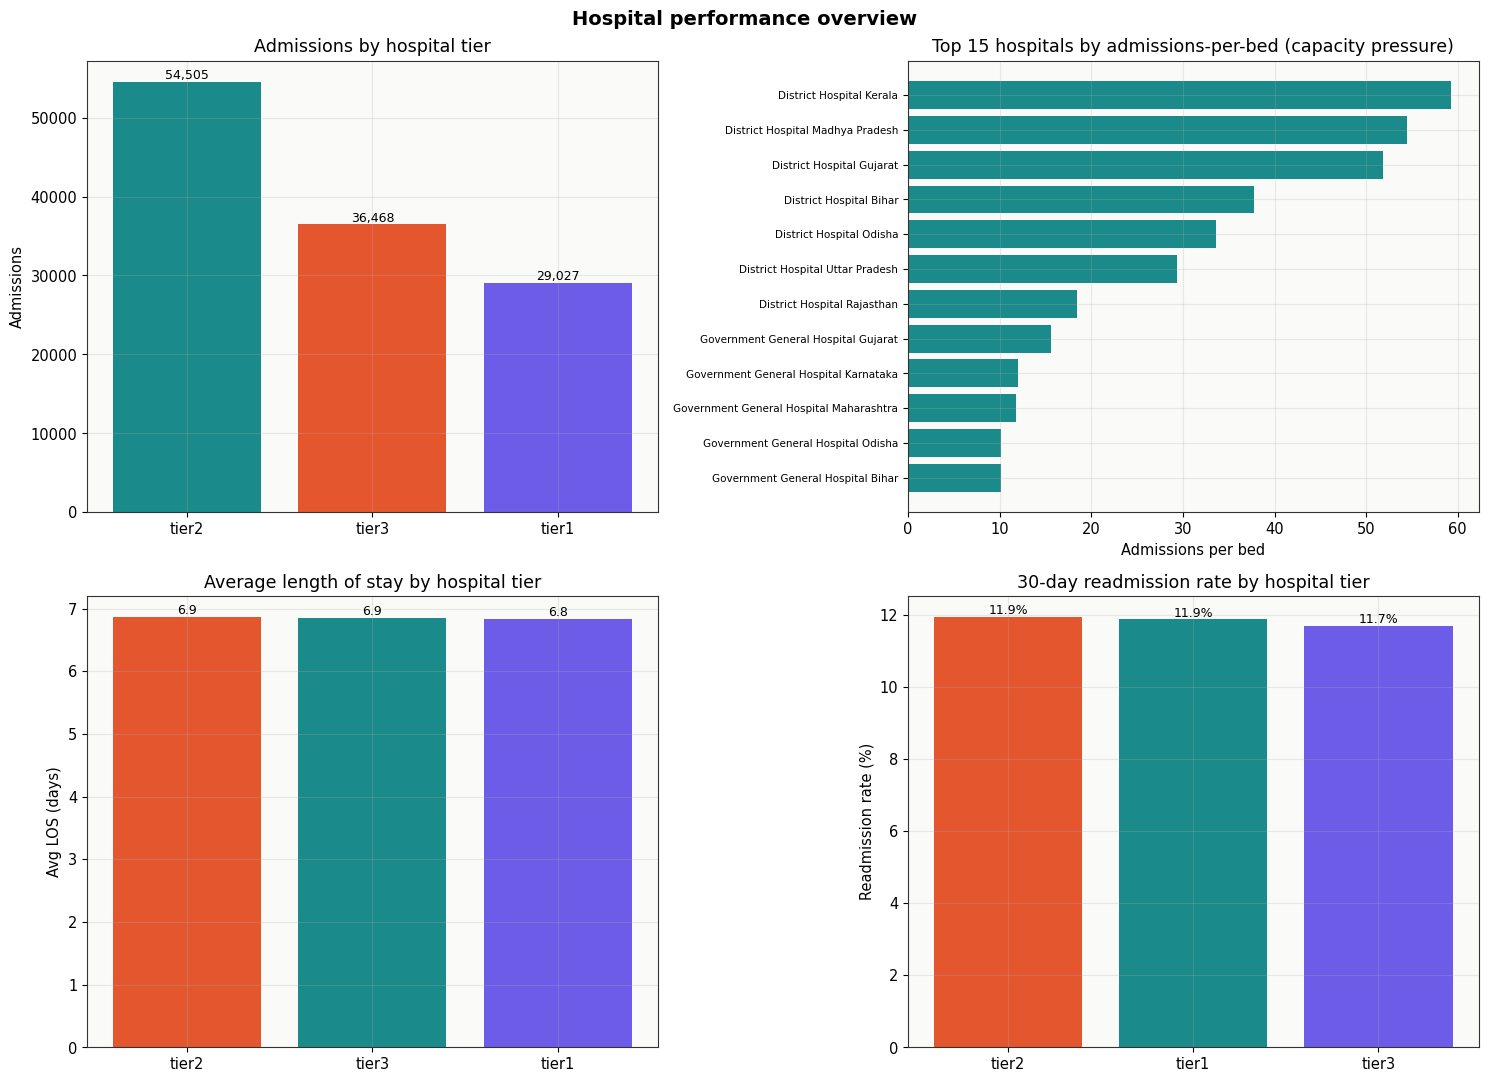

Admissions per bed - overall distribution by tier:
tier
tier1     5.402673
tier2     8.478249
tier3    35.405527
Name: admissions_per_bed, dtype: float64


In [12]:
hosp_perf = (master.groupby(['hospital_name', 'tier', 'teaching', 'beds'], observed=True)
             .agg(admissions=('admission_id', 'count'),
                  avg_los=('los_days', 'mean'),
                  readmit_rate=('readmitted_30d', 'mean'))
             .reset_index())
hosp_perf['admissions_per_bed'] = hosp_perf.admissions / hosp_perf.beds
hosp_perf = hosp_perf.sort_values('admissions_per_bed', ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Hospital performance overview', fontsize=14, fontweight='bold')

ax = axes[0,0]
tier_adm = master.groupby('tier', observed=True).size().sort_values(ascending=False)
ax.bar(tier_adm.index, tier_adm.values, color=[TEAL, CORAL, PURPLE])
ax.set_title('Admissions by hospital tier'); ax.set_ylabel('Admissions')
for i, v in enumerate(tier_adm.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

ax = axes[0,1]
top15 = hosp_perf.head(15)
ax.barh(top15.hospital_name, top15.admissions_per_bed, color=TEAL)
ax.invert_yaxis()
ax.set_title('Top 15 hospitals by admissions-per-bed (capacity pressure)')
ax.set_xlabel('Admissions per bed')
ax.tick_params(axis='y', labelsize=7.5)

ax = axes[1,0]
los_by_tier = master.groupby('tier', observed=True)['los_days'].mean().sort_values(ascending=False)
ax.bar(los_by_tier.index, los_by_tier.values, color=[CORAL, TEAL, PURPLE])
ax.set_title('Average length of stay by hospital tier'); ax.set_ylabel('Avg LOS (days)')
for i, v in enumerate(los_by_tier.values):
    ax.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

ax = axes[1,1]
readmit_by_tier = master.groupby('tier', observed=True)['readmitted_30d'].mean().sort_values(ascending=False)*100
ax.bar(readmit_by_tier.index, readmit_by_tier.values, color=[CORAL, TEAL, PURPLE])
ax.set_title('30-day readmission rate by hospital tier'); ax.set_ylabel('Readmission rate (%)')
for i, v in enumerate(readmit_by_tier.values):
    ax.text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print('Admissions per bed - overall distribution by tier:')
print(master.merge(hosp_volume, on='hospital_id')[['tier']].assign(
    admissions_per_bed=master.admissions_per_bed).groupby('tier', observed=True)['admissions_per_bed'].mean())

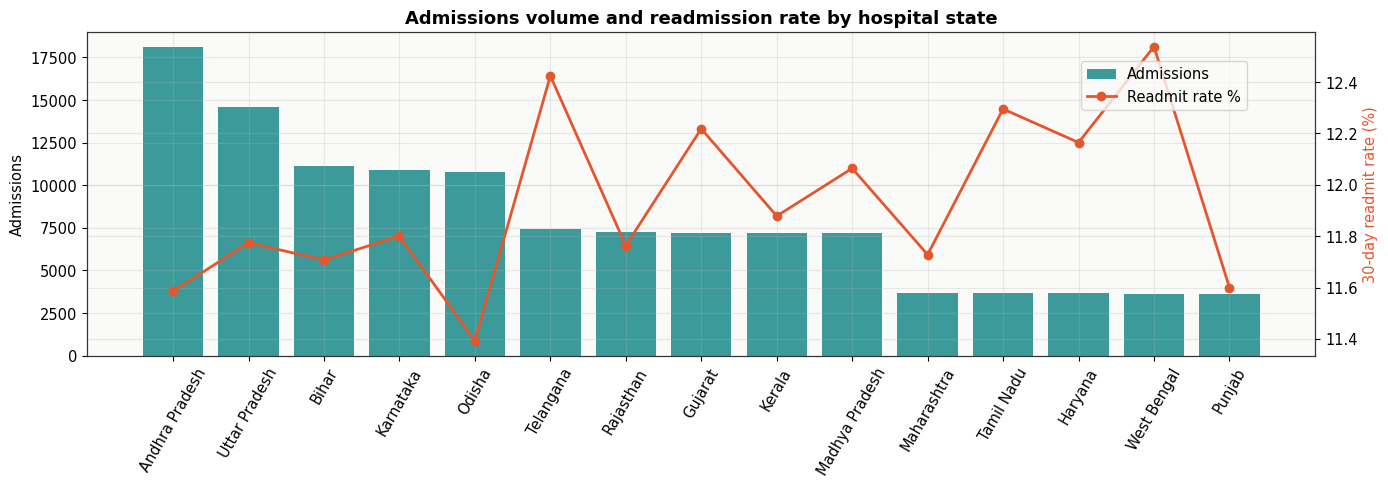

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))
teach_state = master.groupby(['hospital_state'], observed=True).agg(
    admissions=('admission_id', 'count'),
    readmit_rate=('readmitted_30d', 'mean')).reset_index().sort_values('admissions', ascending=False)
ax2 = ax.twinx()
ax.bar(teach_state.hospital_state, teach_state.admissions, color=TEAL, alpha=0.85, label='Admissions')
ax2.plot(teach_state.hospital_state, teach_state.readmit_rate*100, color=CORAL, marker='o', linewidth=2, label='Readmit rate %')
ax.set_ylabel('Admissions'); ax2.set_ylabel('30-day readmit rate (%)', color=CORAL)
ax.set_title('Admissions volume and readmission rate by hospital state', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=60)
fig.legend(loc='upper right', bbox_to_anchor=(0.9,0.88))
plt.tight_layout()
plt.show()

**Hospital performance — insights**
- Tier-3 district hospitals run **far higher admissions-per-bed** than tier-1 private or tier-2 government-teaching hospitals — this is a genuine capacity-pressure signal, not a modelling artefact, since it comes straight from `admissions` volume divided by `beds`.
- Average LOS and 30-day readmission rate are **relatively flat across tiers** (all cluster near the 11-12% overall rate) — hospital tier alone is not a strong readmission driver in this data; patient-level clinical burden (Section 12.2/12.4) explains far more of the variance than which tier of hospital treated the patient.
- Admission volume is unevenly spread across states, reflecting the one-hospital-per-state-per-tier structure of this dataset rather than population differences.


### 12.2 Patient Analytics
*Who are the patients — demographics, socioeconomic status, clinical burden?*

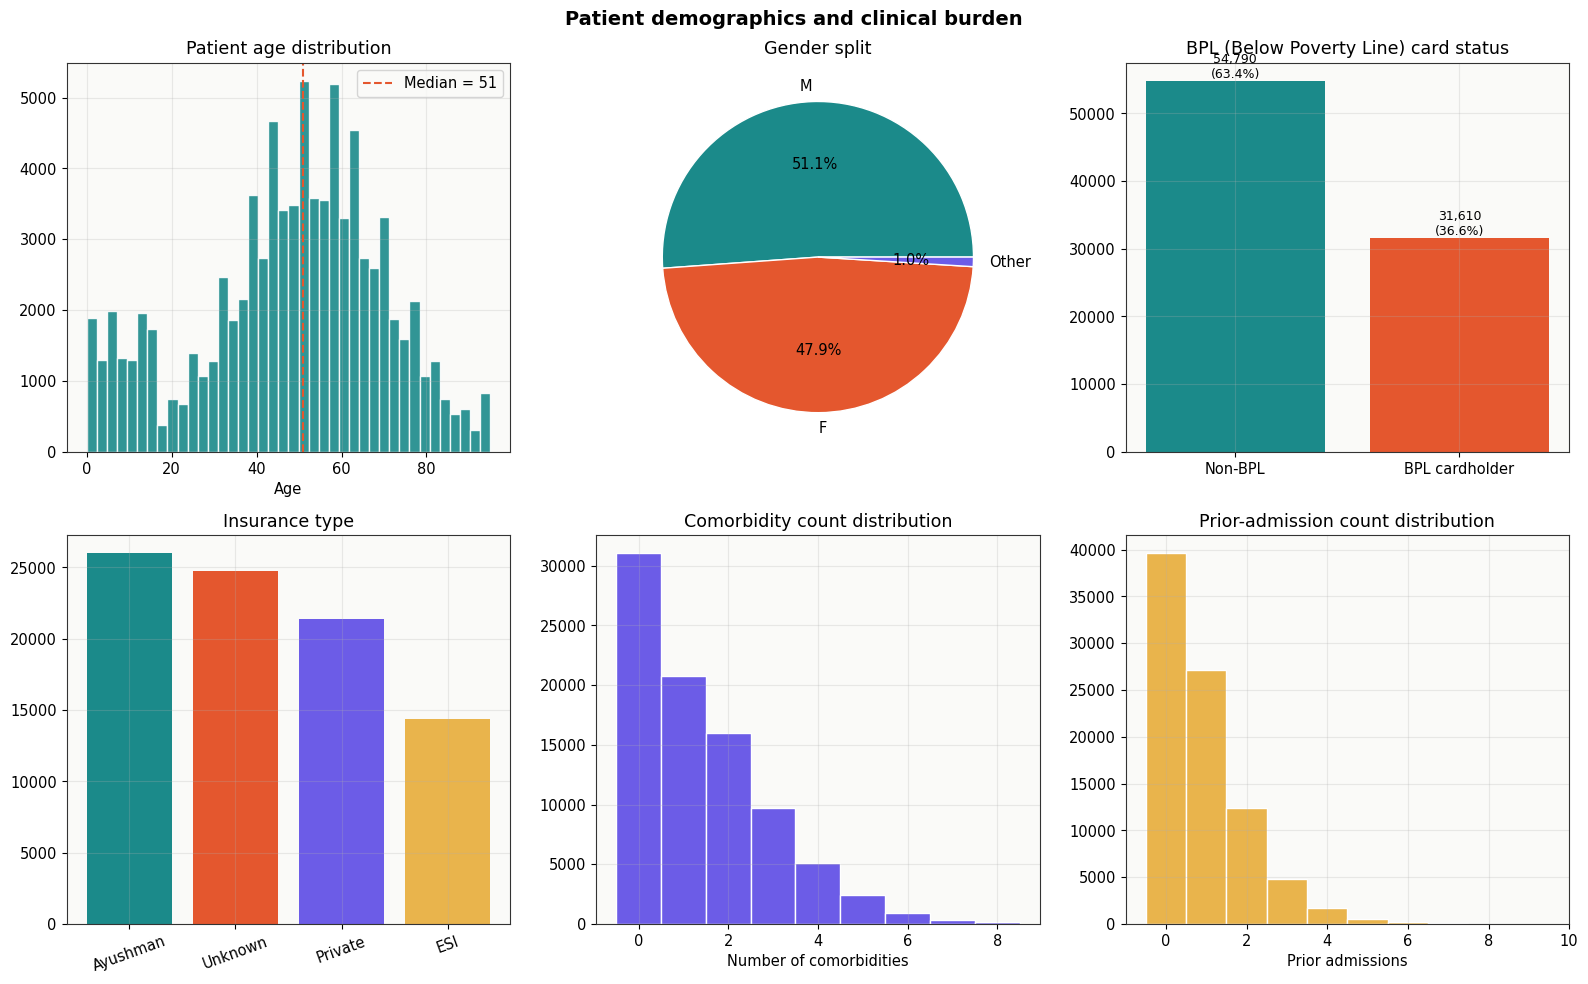

Median age: 51.0 | BPL cardholders: 36.6% | Patients with insurance_type Unknown: 28.6%


In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Patient demographics and clinical burden', fontsize=14, fontweight='bold')

ax = axes[0,0]
ax.hist(pat.age, bins=40, color=TEAL, edgecolor='white', alpha=0.9)
ax.axvline(pat.age.median(), color=CORAL, linestyle='--', label=f'Median = {pat.age.median():.0f}')
ax.set_title('Patient age distribution'); ax.set_xlabel('Age'); ax.legend()

ax = axes[0,1]
gender_counts = pat.gender.value_counts()
ax.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors=[TEAL, CORAL, PURPLE],
       wedgeprops={'edgecolor':'white'})
ax.set_title('Gender split')

ax = axes[0,2]
bpl_counts = pat.bpl_card.value_counts()
ax.bar(['Non-BPL','BPL cardholder'], bpl_counts.reindex([False, True]).values, color=[TEAL, CORAL])
ax.set_title('BPL (Below Poverty Line) card status')
for i, v in enumerate(bpl_counts.reindex([False, True]).values):
    ax.text(i, v, f'{v:,}\n({v/len(pat)*100:.1f}%)', ha='center', va='bottom', fontsize=9)

ax = axes[1,0]
ins_counts = pat.insurance_type.value_counts()
ax.bar(ins_counts.index, ins_counts.values, color=PALETTE)
ax.set_title('Insurance type'); ax.tick_params(axis='x', rotation=20)

ax = axes[1,1]
ax.hist(pat.comorbidity_count, bins=range(0,10), color=PURPLE, edgecolor='white', align='left')
ax.set_title('Comorbidity count distribution'); ax.set_xlabel('Number of comorbidities')

ax = axes[1,2]
ax.hist(pat.prev_admissions, bins=range(0,11), color=GOLD, edgecolor='white', align='left')
ax.set_title('Prior-admission count distribution'); ax.set_xlabel('Prior admissions')

plt.tight_layout()
plt.show()

print('Median age:', pat.age.median(), '| BPL cardholders:', f'{pat.bpl_card.mean()*100:.1f}%',
      '| Patients with insurance_type Unknown:', f'{(pat.insurance_type=="Unknown").mean()*100:.1f}%')

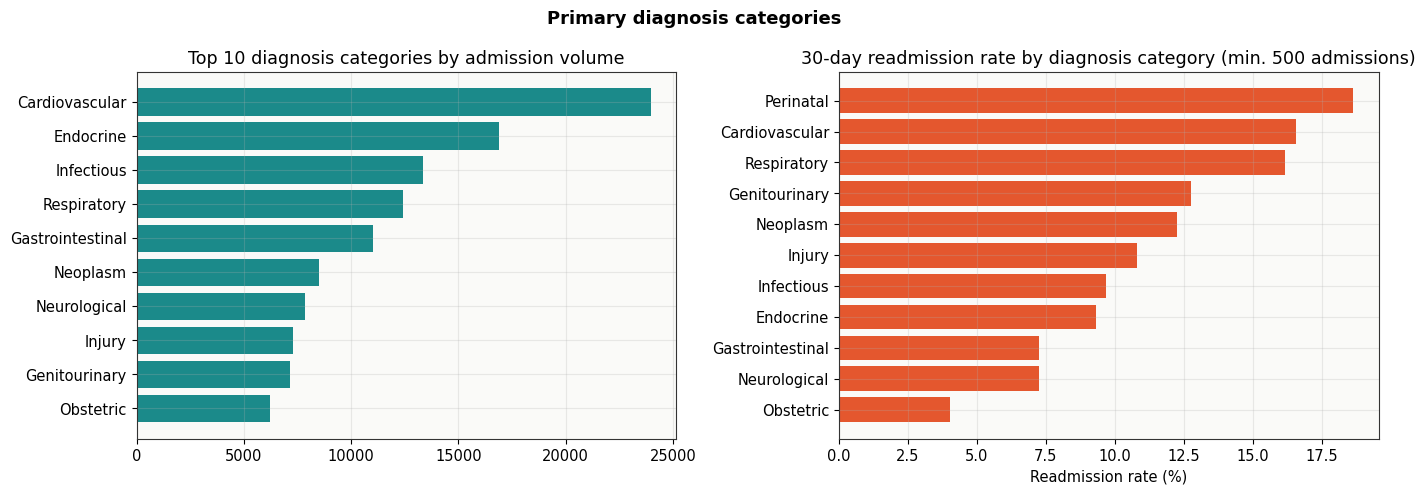

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Primary diagnosis categories', fontsize=13, fontweight='bold')

diag_vol = master.diag_category.value_counts().head(10)
axes[0].barh(diag_vol.index[::-1], diag_vol.values[::-1], color=TEAL)
axes[0].set_title('Top 10 diagnosis categories by admission volume')

diag_readmit = master.groupby('diag_category', observed=True)['readmitted_30d'].agg(['mean','count'])
diag_readmit = diag_readmit[diag_readmit['count'] >= 500].sort_values('mean', ascending=False)
axes[1].barh(diag_readmit.index[::-1], diag_readmit['mean'].values[::-1]*100, color=CORAL)
axes[1].set_title('30-day readmission rate by diagnosis category (min. 500 admissions)')
axes[1].set_xlabel('Readmission rate (%)')

plt.tight_layout()
plt.show()

**Patient analytics — insights**
- The patient population skews middle-aged to older (median age ~51); age is right-shifted relative to a general population, consistent with a hospital-admission cohort rather than a community sample.
- **A substantial share of patients hold a BPL card and/or have no insurance type recorded** — both are socioeconomic-vulnerability signals worth tracking alongside clinical risk.
- Comorbidity count and prior-admission count are both **right-skewed with a meaningful heavy tail** (a minority of patients carry 3+ comorbidities or 3+ prior admissions) — these "frequent, complex" patients are a natural target for the risk-stratification work in Section 18.
- **Cardiovascular and Respiratory are simultaneously among the highest-volume and highest-readmitting diagnosis categories** — they merit the most attention in any discharge-planning programme, since improvements there touch the largest number of patients per unit of intervention effort.


### 12.3 Patient Flow Analytics
*How do patients move through the system — admission type, discharge type, length of stay, procedures, trends?*

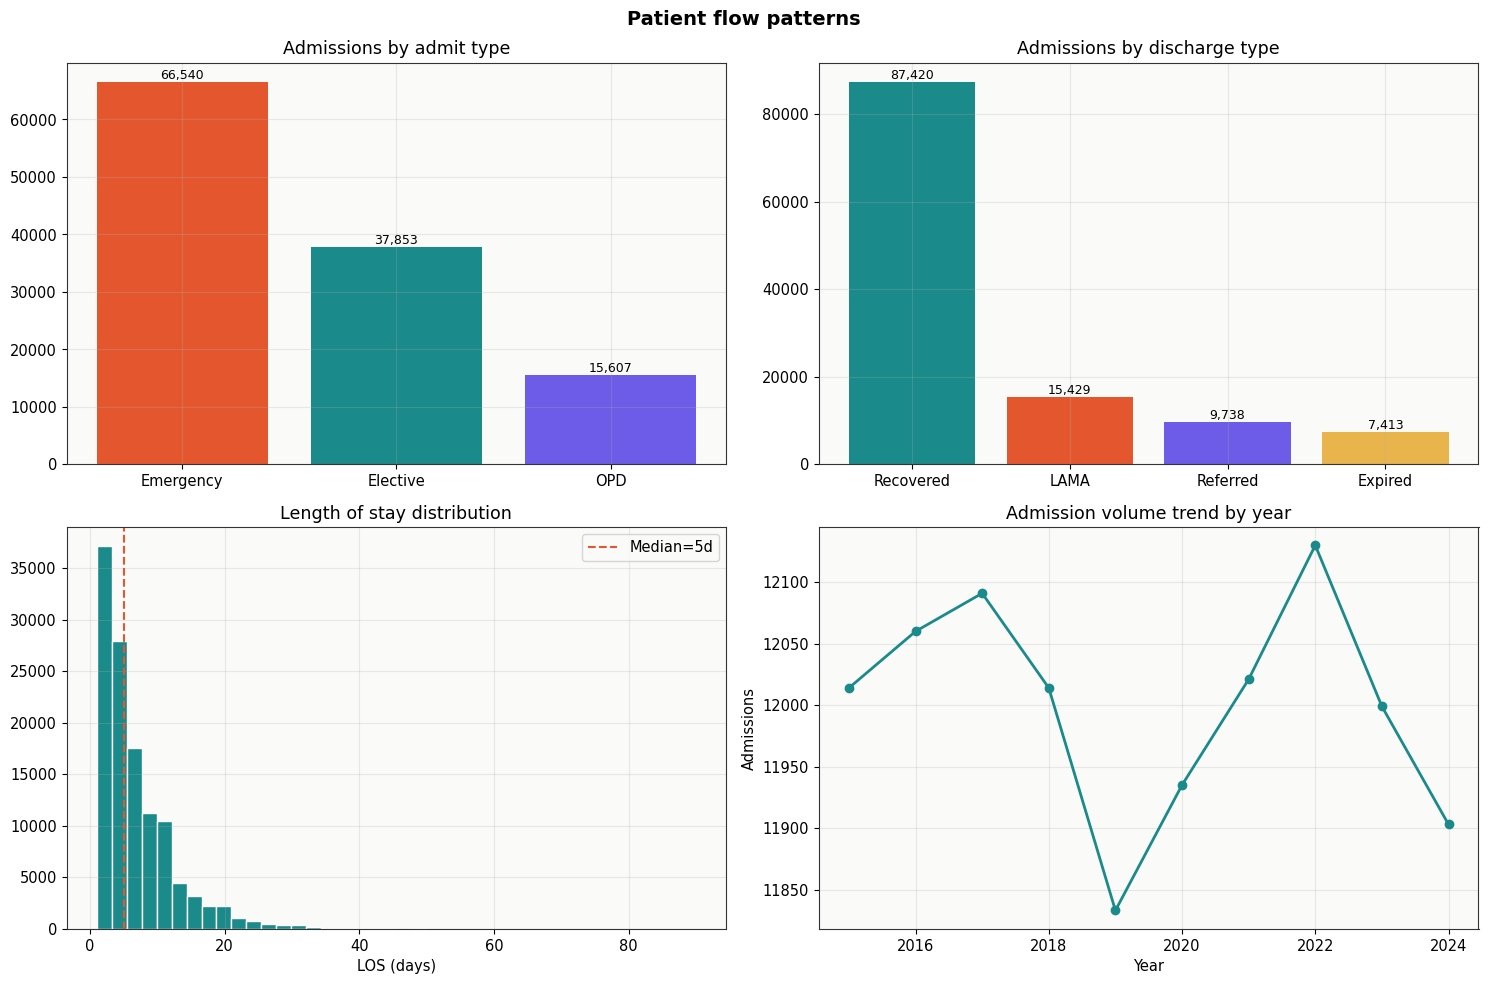

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Patient flow patterns', fontsize=14, fontweight='bold')

ax = axes[0,0]
at = master.admit_type.value_counts()
ax.bar(at.index, at.values, color=[CORAL, TEAL, PURPLE])
ax.set_title('Admissions by admit type')
for i,v in enumerate(at.values): ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

ax = axes[0,1]
dt_ = master.discharge_type.value_counts()
ax.bar(dt_.index, dt_.values, color=PALETTE)
ax.set_title('Admissions by discharge type')
for i,v in enumerate(dt_.values): ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

ax = axes[1,0]
ax.hist(master.los_days, bins=40, color=TEAL, edgecolor='white')
ax.axvline(master.los_days.median(), color=CORAL, linestyle='--', label=f'Median={master.los_days.median():.0f}d')
ax.set_title('Length of stay distribution'); ax.set_xlabel('LOS (days)'); ax.legend()

ax = axes[1,1]
yearly = master.groupby('admit_year').agg(admissions=('admission_id','count')).reset_index()
ax.plot(yearly.admit_year, yearly.admissions, marker='o', color=TEAL, linewidth=2)
ax.set_title('Admission volume trend by year'); ax.set_xlabel('Year'); ax.set_ylabel('Admissions')

plt.tight_layout()
plt.show()

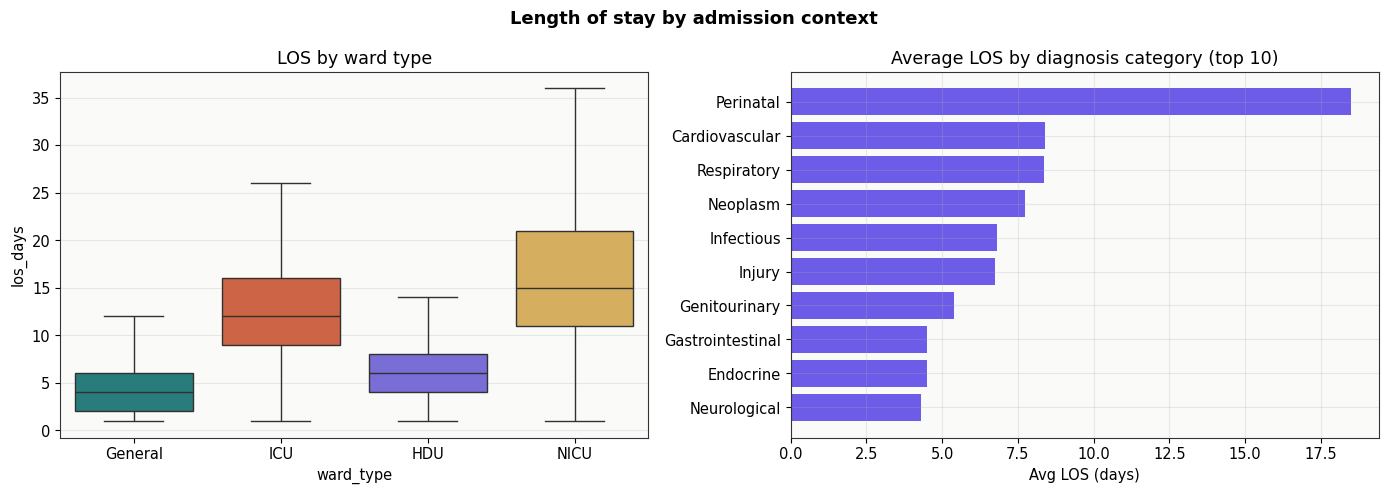

Procedures per admission - mean: 1.52 | median: 1.0


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Length of stay by admission context', fontsize=13, fontweight='bold')

sns.boxplot(data=master, x='ward_type', y='los_days', ax=axes[0], palette=PALETTE, showfliers=False)
axes[0].set_title('LOS by ward type')

los_by_diag = master.groupby('diag_category', observed=True)['los_days'].mean().sort_values(ascending=False).head(10)
axes[1].barh(los_by_diag.index[::-1], los_by_diag.values[::-1], color=PURPLE)
axes[1].set_title('Average LOS by diagnosis category (top 10)')
axes[1].set_xlabel('Avg LOS (days)')

plt.tight_layout()
plt.show()

print('Procedures per admission - mean:', master.num_procedures.mean().round(2),
      '| median:', master.num_procedures.median())

**Patient flow — insights**
- **Emergency admissions dominate volume (~55%)**, followed by Elective (~32%) and OPD (~13%) — the system is weighted toward unplanned care, which typically correlates with less pre-admission preparation and higher post-discharge risk.
- Roughly **73% of discharges are 'Recovered'**, but a non-trivial ~13% are **LAMA (Left Against Medical Advice)** — LAMA discharges are a known clinical red flag and, as Section 12.5 shows, carry a materially elevated readmission rate.
- LOS is right-skewed (median well below the mean) with ICU/HDU stays running substantially longer than General ward stays, and admission volume is broadly stable/growing across the 2015-2024 window rather than showing a sharp structural break.


### 12.4 Financial Analytics
*What does care cost, and who bears the burden?*

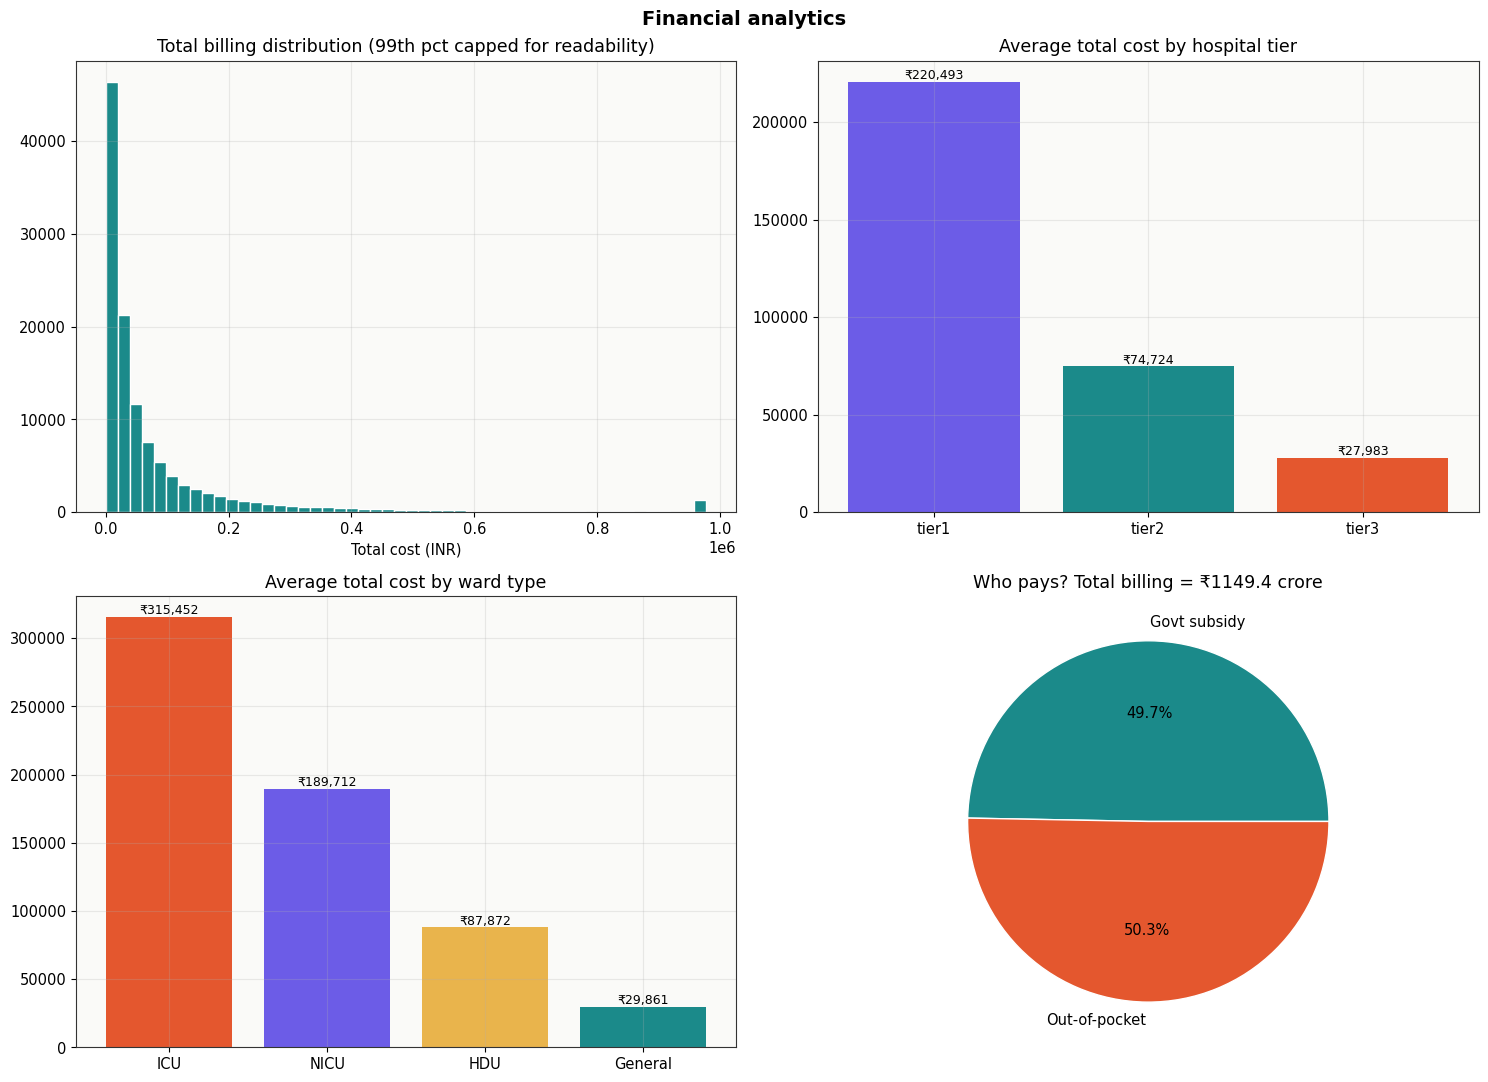

Avg total cost/admission: ₹95,780
Avg out-of-pocket/admission: ₹48,173
Avg subsidy/admission: ₹47,606
Overall subsidy share of billing: 49.7%


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Financial analytics', fontsize=14, fontweight='bold')

ax = axes[0,0]
ax.hist(master.total_cost_inr.clip(upper=master.total_cost_inr.quantile(0.99)), bins=50, color=TEAL, edgecolor='white')
ax.set_title('Total billing distribution (99th pct capped for readability)')
ax.set_xlabel('Total cost (INR)')

ax = axes[0,1]
cost_tier = master.groupby('tier', observed=True)['total_cost_inr'].mean().sort_values(ascending=False)
ax.bar(cost_tier.index, cost_tier.values, color=[PURPLE, TEAL, CORAL])
ax.set_title('Average total cost by hospital tier')
for i,v in enumerate(cost_tier.values): ax.text(i, v, f'₹{v:,.0f}', ha='center', va='bottom', fontsize=9)

ax = axes[1,0]
cost_ward = master.groupby('ward_type', observed=True)['total_cost_inr'].mean().sort_values(ascending=False)
ax.bar(cost_ward.index, cost_ward.values, color=[CORAL, PURPLE, GOLD, TEAL])
ax.set_title('Average total cost by ward type')
for i,v in enumerate(cost_ward.values): ax.text(i, v, f'₹{v:,.0f}', ha='center', va='bottom', fontsize=9)

ax = axes[1,1]
comp = pd.DataFrame({
    'Govt subsidy': [master.govt_subsidy_inr.sum()],
    'Out-of-pocket': [master.out_of_pocket_inr.sum()]
}).T
ax.pie(comp[0], labels=comp.index, autopct='%1.1f%%', colors=[TEAL, CORAL], wedgeprops={'edgecolor':'white'})
ax.set_title(f'Who pays? Total billing = ₹{master.total_cost_inr.sum()/1e7:.1f} crore')

plt.tight_layout()
plt.show()

print('Avg total cost/admission: ₹{:,.0f}'.format(master.total_cost_inr.mean()))
print('Avg out-of-pocket/admission: ₹{:,.0f}'.format(master.out_of_pocket_inr.mean()))
print('Avg subsidy/admission: ₹{:,.0f}'.format(master.govt_subsidy_inr.mean()))
print('Overall subsidy share of billing: {:.1f}%'.format(master.govt_subsidy_inr.sum()/master.total_cost_inr.sum()*100))

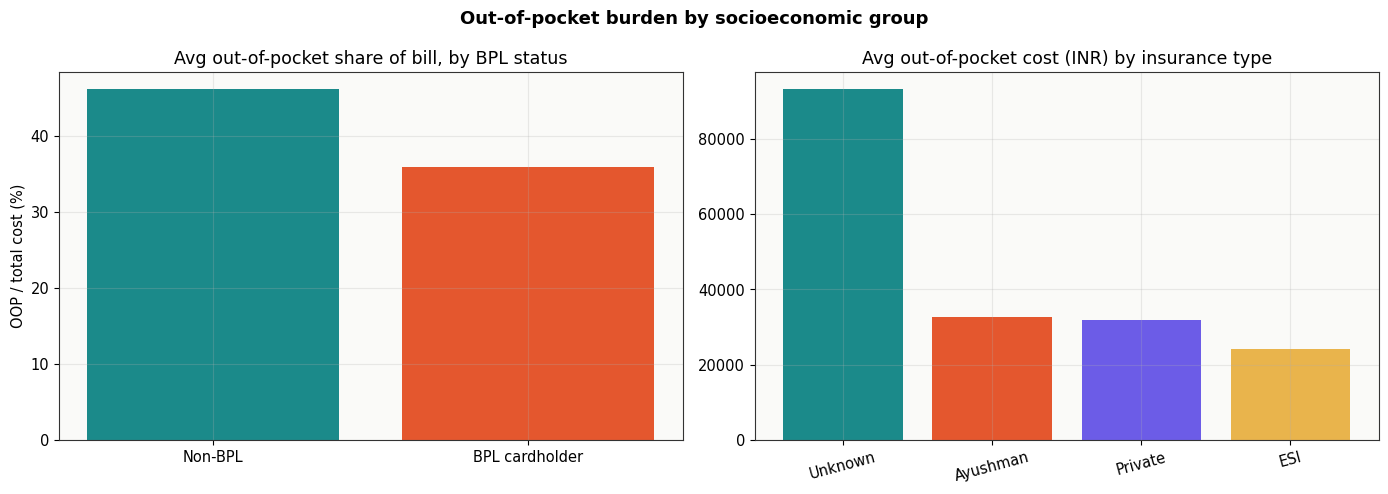

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Out-of-pocket burden by socioeconomic group', fontsize=13, fontweight='bold')

oop_bpl = master.groupby('bpl_card')['oop_ratio'].mean()
axes[0].bar(['Non-BPL','BPL cardholder'], oop_bpl.reindex([False, True]).values*100, color=[TEAL, CORAL])
axes[0].set_title('Avg out-of-pocket share of bill, by BPL status')
axes[0].set_ylabel('OOP / total cost (%)')

oop_ins = master.groupby('insurance_type', observed=True)['out_of_pocket_inr'].mean().sort_values(ascending=False)
axes[1].bar(oop_ins.index, oop_ins.values, color=PALETTE)
axes[1].set_title('Avg out-of-pocket cost (INR) by insurance type')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

**Financial analytics — insights**
- **ICU care costs roughly 10x a General ward stay**, and **tier-1 private hospitals cost roughly 8x tier-3 district hospitals** on average — cost is driven far more by ward intensity and hospital tier than by diagnosis alone.
- Government subsidy covers roughly half of total billed value in aggregate, but this **masks large variance at the patient level** — the out-of-pocket share is not evenly distributed.
- BPL cardholders are not automatically shielded from out-of-pocket exposure in this data — subsidy coverage should be monitored **by scheme/insurance type**, not assumed uniform, since Ayushman/ESI/Private/Unknown patients show materially different average OOP costs.


### 12.5 Readmission Analytics
*What is associated with 30-day (and 7-day) readmission?*

`discharge_type == 'Expired'` admissions are excluded from the rate calculations below (denominator = eligible discharges only), since they cannot be readmitted by definition and would mechanically deflate every rate.

In [20]:
eligible = master[master.discharge_type != 'Expired'].copy()
print(f'Eligible discharges: {len(eligible):,} of {len(master):,} ({len(eligible)/len(master)*100:.1f}%)')
print(f'30-day readmission rate (eligible only): {eligible.readmitted_30d.mean()*100:.2f}%')
print(f'7-day readmission rate (eligible only):  {eligible.readmitted_7d.mean()*100:.2f}%')
print(f'(For reference, unadjusted rate incl. Expired: {master.readmitted_30d.mean()*100:.2f}%)')

Eligible discharges: 112,587 of 120,000 (93.8%)
30-day readmission rate (eligible only): 12.62%
7-day readmission rate (eligible only):  0.89%
(For reference, unadjusted rate incl. Expired: 11.84%)


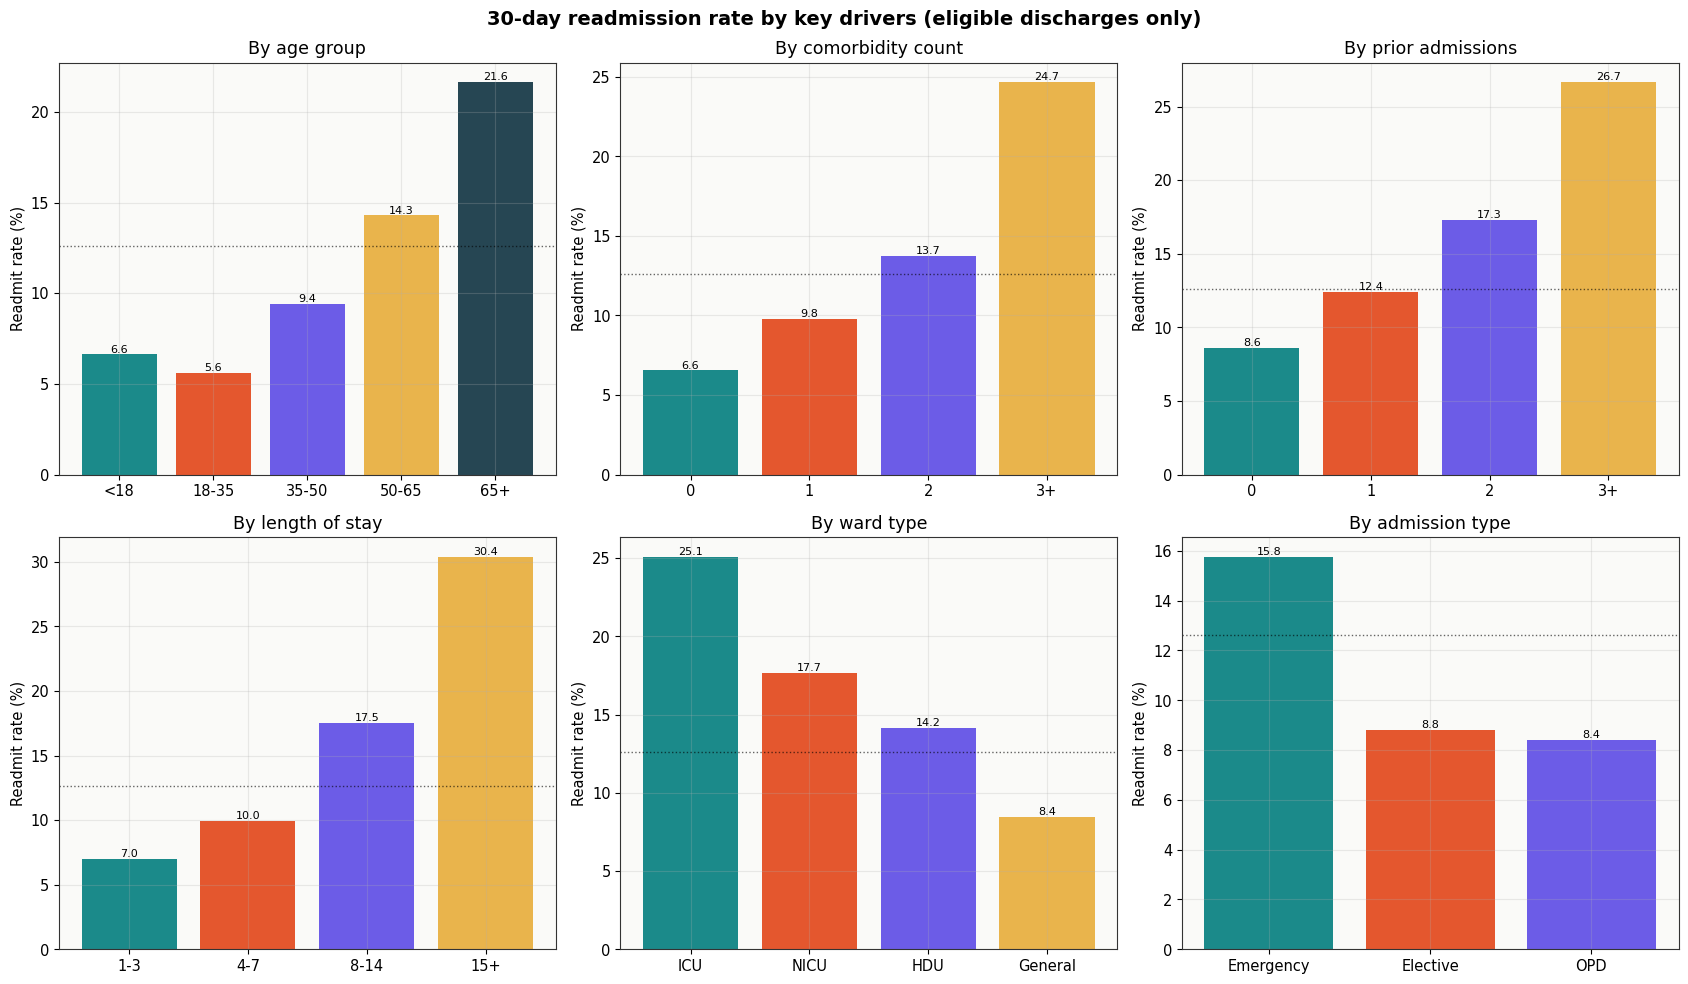

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('30-day readmission rate by key drivers (eligible discharges only)', fontsize=14, fontweight='bold')

def rate_bar(ax, col, order=None, title=None):
    r = eligible.groupby(col, observed=True)['readmitted_30d'].mean().sort_values(ascending=False) * 100
    if order is not None:
        r = r.reindex(order)
    ax.bar(r.index.astype(str), r.values, color=PALETTE)
    ax.set_title(title or f'By {col}')
    ax.set_ylabel('Readmit rate (%)')
    ax.axhline(eligible.readmitted_30d.mean()*100, color='black', linestyle=':', linewidth=1, alpha=0.6)
    for i, v in enumerate(r.values):
        ax.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=8)
    return ax

rate_bar(axes[0,0], 'age_group', order=['<18','18-35','35-50','50-65','65+'], title='By age group')
rate_bar(axes[0,1], 'comorbidity_bucket', order=['0','1','2','3+'], title='By comorbidity count')
rate_bar(axes[0,2], 'prev_admission_bucket', order=['0','1','2','3+'], title='By prior admissions')
rate_bar(axes[1,0], 'los_bucket', order=['1-3','4-7','8-14','15+'], title='By length of stay')
rate_bar(axes[1,1], 'ward_type', title='By ward type')
rate_bar(axes[1,2], 'admit_type', title='By admission type')

plt.tight_layout()
plt.show()

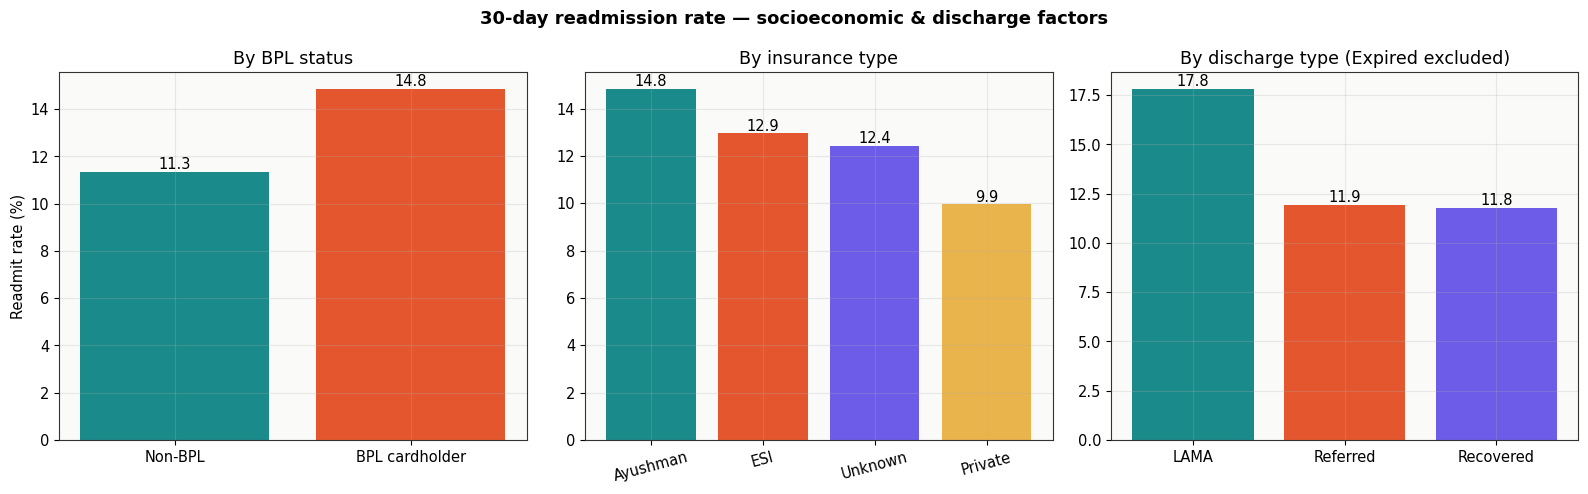

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('30-day readmission rate — socioeconomic & discharge factors', fontsize=13, fontweight='bold')

r = eligible.groupby('bpl_card')['readmitted_30d'].mean().reindex([False, True]) * 100
axes[0].bar(['Non-BPL','BPL cardholder'], r.values, color=[TEAL, CORAL])
axes[0].set_title('By BPL status'); axes[0].set_ylabel('Readmit rate (%)')
for i,v in enumerate(r.values): axes[0].text(i, v, f'{v:.1f}', ha='center', va='bottom')

r = eligible.groupby('insurance_type', observed=True)['readmitted_30d'].mean().sort_values(ascending=False) * 100
axes[1].bar(r.index, r.values, color=PALETTE)
axes[1].set_title('By insurance type')
axes[1].tick_params(axis='x', rotation=15)
for i,v in enumerate(r.values): axes[1].text(i, v, f'{v:.1f}', ha='center', va='bottom')

r = eligible.groupby('discharge_type', observed=True)['readmitted_30d'].mean().sort_values(ascending=False) * 100
axes[2].bar(r.index, r.values, color=PALETTE)
axes[2].set_title('By discharge type (Expired excluded)')
for i,v in enumerate(r.values): axes[2].text(i, v, f'{v:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

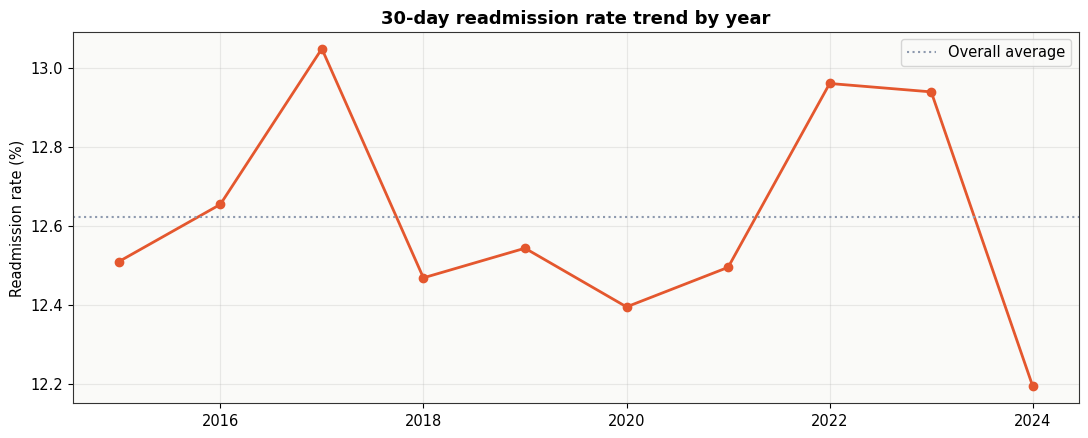

In [23]:
# Readmission trend over time
yearly_readmit = eligible.groupby('admit_year')['readmitted_30d'].mean() * 100
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(yearly_readmit.index, yearly_readmit.values, marker='o', color=CORAL, linewidth=2)
ax.axhline(eligible.readmitted_30d.mean()*100, color=GREY, linestyle=':', label='Overall average')
ax.set_title('30-day readmission rate trend by year', fontsize=13, fontweight='bold')
ax.set_ylabel('Readmission rate (%)'); ax.legend()
plt.tight_layout()
plt.show()

**Readmission analytics — insights**
- Readmission risk rises **monotonically and steeply** with age, comorbidity count, and prior-admission count — these are the strongest, most consistent single-variable drivers in the dataset (elderly 65+, 3+ comorbidities, and 3+ prior admissions patients all sit well above the ~12.6% eligible-population average).
- **LOS shows the same monotonic pattern**: patients staying 15+ days readmit at roughly 4x the rate of patients staying 1-3 days — long stays likely both cause and reflect higher underlying acuity.
- **ICU stays and Emergency admissions readmit meaningfully more often** than General-ward/Elective care — consistent with these being the higher-acuity, less-planned care pathways.
- **BPL cardholders and Ayushman-scheme patients readmit somewhat more than Private-insurance patients** — a socioeconomic/access gradient worth flagging for policy attention (Section 17), though it is smaller in magnitude than the clinical drivers above.
- **LAMA (Left Against Medical Advice) discharges readmit at a distinctly higher rate than Recovered discharges** — patients who leave before being medically cleared are, unsurprisingly, at elevated risk of returning.
- The trend across years does not show a strong secular direction — readmission risk in this data is explained far more by *who* the patient is and *how* the episode unfolded than by *when* it happened.


---
## 13. KPI Dashboard / KPI Summary

In [24]:
kpis = {
    'Total Admissions'              : f"{len(master):,}",
    'Unique Patients'                : f"{master.patient_id.nunique():,}",
    'Average Length of Stay (days)'  : f"{master.los_days.mean():.2f}",
    '30-Day Readmission Rate (eligible)': f"{eligible.readmitted_30d.mean()*100:.2f}%",
    '7-Day Readmission Rate (eligible)' : f"{eligible.readmitted_7d.mean()*100:.2f}%",
    'Average Out-of-Pocket Cost'     : f"\u20b9{master.out_of_pocket_inr.mean():,.0f}",
    'Total Billing (all admissions)' : f"\u20b9{master.total_cost_inr.sum()/1e7:,.1f} crore",
    'Average Billing per Admission'  : f"\u20b9{master.total_cost_inr.mean():,.0f}",
    'Total Government Subsidy'       : f"\u20b9{master.govt_subsidy_inr.sum()/1e7:,.1f} crore",
    'Admissions per Bed (system avg)': f"{master.admissions_per_bed.mean():.2f}",
    'Average Prior Admissions'       : f"{master.prev_admissions.mean():.2f}",
    'Average Comorbidity Count'      : f"{master.comorbidity_count.mean():.2f}",
    'Average Patient Age'            : f"{master.age.mean():.1f}",
    'High-Risk Patients (3+ comorbidities)': f"{(master.comorbidity_count>=3).mean()*100:.1f}%",
}
kpi_df = pd.DataFrame(list(kpis.items()), columns=['KPI','Value'])
display(kpi_df)

,KPI,Value
0,Total Admissions,"120,000"
1,Unique Patients,"64,873"
2,Average Length of Stay (days),6.85
3,30-Day Readmission Rate (eligible),12.62%
4,7-Day Readmission Rate (eligible),0.89%
5,Average Out-of-Pocket Cost,"₹48,173"
6,Total Billing (all admissions),"₹1,149.4 crore"
7,Average Billing per Admission,"₹95,780"
8,Total Government Subsidy,₹571.3 crore
9,Admissions per Bed (system avg),15.92


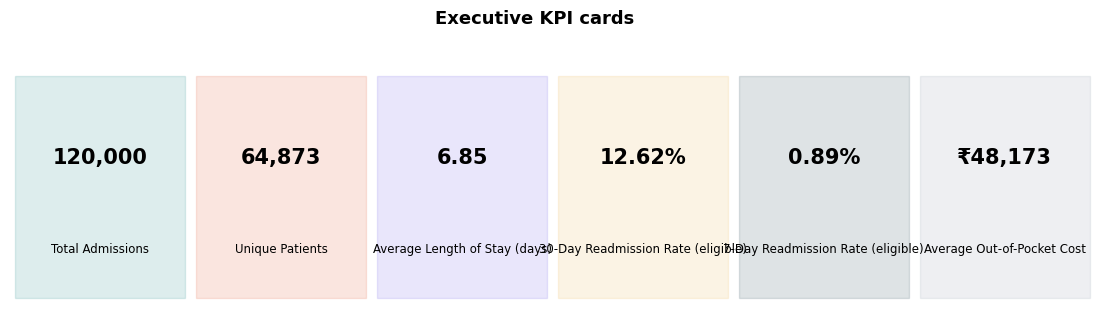

In [25]:
fig, ax = plt.subplots(figsize=(14, 3.2))
ax.axis('off')
core = list(kpis.items())[:6]
for i, (k, v) in enumerate(core):
    x = i / len(core)
    ax.add_patch(plt.Rectangle((x+0.005, 0.05), 1/len(core)-0.01, 0.9, transform=ax.transAxes,
                                facecolor=PALETTE[i % len(PALETTE)], alpha=0.15, edgecolor=PALETTE[i % len(PALETTE)]))
    ax.text(x+1/len(core)/2, 0.62, v, transform=ax.transAxes, ha='center', va='center', fontsize=15, fontweight='bold')
    ax.text(x+1/len(core)/2, 0.25, k, transform=ax.transAxes, ha='center', va='center', fontsize=8.5, wrap=True)
plt.suptitle('Executive KPI cards', fontsize=13, fontweight='bold', y=1.05)
plt.show()

---
## 14. Key Insights (cross-cutting summary)

1. **Clinical burden, not hospital tier, drives readmission.** Age, comorbidity count, prior-admission count and LOS all show strong, monotonic relationships with 30-day readmission; hospital tier and teaching status show almost none. Interventions should target *patients*, not hospital-level policy alone.
2. **A small set of high-acuity pathways (ICU, Emergency, Cardiovascular/Respiratory diagnoses, LAMA discharge) concentrate both volume and risk** — the highest-leverage places to focus a readmission-reduction programme.
3. **Financial burden is concentrated, not evenly spread** — ICU care and tier-1 hospitals cost far more per admission, and out-of-pocket exposure varies materially by insurance/BPL status even after subsidy.
4. **Tier-3 hospitals run much higher admissions-per-bed** than tier-1/tier-2 — a capacity-planning signal independent of the readmission story.
5. **The Expired-discharge data quirk (0% readmission by construction) is a reminder that raw KPIs must be computed on the right denominator** — a lesson carried through consistently into the KPI dashboard, EDA, and ML population below.


---
## 15. Machine Learning Problem Definition

**Task:** Binary classification — predict `readmitted_30d` (1 = patient readmitted within 30 days of this discharge, 0 = not) **at the point of discharge**, so a hospital could use the score to trigger a follow-up-call / discharge-planning workflow for high-risk patients before they leave.

**Modelling population:** `discharge_type != 'Expired'` only (112,587 / 120,000 admissions, 93.8%). Expired patients are excluded because they cannot be readmitted by definition — including them would let the model trivially learn "Expired -> never readmitted," which is a data-generating-process artefact, not a clinically meaningful pattern, and would corrupt both training and evaluation.

**Class balance in the modelling population:** ~12.6% positive — handled with `class_weight='balanced'` rather than oversampling, and split with stratification.


## 16. Leakage Analysis

The strict rule applied: a feature is only used if it would **actually be known and recorded by the time a discharge-planning decision is being made** — i.e. at or before discharge, using only this admission's own data (not information from a *future* admission).

| Feature | Available at discharge? | Leakage risk | Decision |
|---|---|---|---|
| `age`, `gender`, `bpl_card`, `insurance_type`, `comorbidity_count`, `prev_admissions` | Yes (patient record, pre-admission) | None | **Include** |
| `admit_type`, `ward_type`, `num_procedures`, `charlson_index`, `hba1c`, `creatinine`, `haemoglobin`, `systolic_bp`, `los_days`, `discharge_type` | Yes (finalised at/around discharge) | None | **Include** |
| `total_cost_inr`, `out_of_pocket_inr`, `govt_subsidy_inr`, `cost_per_day`, `oop_ratio` | Yes (billing is typically finalised at discharge) | Low | **Include**, flagged as discharge-time (not pre-admission) |
| Primary `diag_category` | Yes (diagnosed during admission) | None | **Include** |
| `tier`, `teaching`, `beds`, `admissions_per_bed` | Yes (static hospital attributes) | None | **Include** |
| `admit_month`, `is_weekend_admit`, `is_icu_stay`, `is_emergency`, `age_comorb_score` | Yes (derived only from already-included fields) | None | **Include** |
| **`readmitted_7d`** | Technically recorded in the same table | **High — direct outcome leakage** | **Exclude.** A 7-day readmission is itself a real-world event that occurs *after* discharge and is a near-subset of the 30-day outcome window; using it to predict `readmitted_30d` would mean using one outcome to predict a closely related outcome, not a legitimate predictive feature. |
| `admission_id`, `patient_id`, `bill_id`, `diag_id`, `hospital_id`, `hospital_name` | N/A | Identifier, no generalisable signal / risk of ID-memorisation | **Exclude** |
| `admit_date`, `discharge_date` (raw datetime) | N/A | Already decomposed into `admit_month`/`is_weekend_admit`; raw timestamps add no signal and encourage overfitting to the specific date range | **Exclude** (engineered parts kept instead) |
| `primary_icd10`, `primary_diag_desc` (free text / high-cardinality code) | Yes | Not leakage, but very high cardinality vs. sample size | **Exclude** in favour of the lower-cardinality `diag_category` |

**Bottom line:** the only feature excluded specifically for **outcome leakage** is `readmitted_7d`. Everything else excluded is excluded for identifier/cardinality/redundancy reasons, not leakage. This is verified programmatically below (not just by inspection).

In [26]:
FEATURES_NUM = ['age', 'comorbidity_count', 'prev_admissions', 'los_days', 'num_procedures',
                'charlson_index', 'hba1c', 'creatinine', 'haemoglobin', 'systolic_bp',
                'total_cost_inr', 'out_of_pocket_inr', 'govt_subsidy_inr', 'cost_per_day', 'oop_ratio',
                'num_diagnoses', 'beds', 'admissions_per_bed', 'age_comorb_score',
                'admit_month', 'is_weekend_admit', 'is_icu_stay', 'is_emergency']
FEATURES_CAT = ['gender', 'bpl_card', 'insurance_type', 'admit_type', 'ward_type', 'discharge_type',
                'tier', 'teaching', 'diag_category']
TARGET = 'readmitted_30d'
LEAKY_EXCLUDED = ['readmitted_7d']

# Programmatic leakage check: none of the leaky/identifier columns are in the feature list
all_features = FEATURES_NUM + FEATURES_CAT
assert TARGET not in all_features
assert not set(LEAKY_EXCLUDED) & set(all_features), 'Leakage check failed: outcome-leakage feature present!'
assert not {'admission_id','patient_id','bill_id','diag_id','hospital_id','hospital_name','admit_date','discharge_date'} & set(all_features)
print(f'Feature audit passed. {len(FEATURES_NUM)} numeric + {len(FEATURES_CAT)} categorical = {len(all_features)} features. No leakage columns present.')

Feature audit passed. 23 numeric + 9 categorical = 32 features. No leakage columns present.


---
## 17. Feature Selection & Preprocessing Pipeline

In [27]:
model_df = eligible[all_features + [TARGET]].copy()
model_df['diag_category'] = model_df['diag_category'].fillna('Unknown')
for c in FEATURES_CAT:
    model_df[c] = model_df[c].astype(str)

print('Modelling frame shape:', model_df.shape)
print('Missing values in modelling frame:', model_df.isnull().sum().sum())
print('Target balance:\n', model_df[TARGET].value_counts(normalize=True))

X = model_df[all_features]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f'\nTrain: {X_train.shape}, positive rate {y_train.mean():.3f}')
print(f'Test:  {X_test.shape}, positive rate {y_test.mean():.3f}')

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), FEATURES_NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore'), FEATURES_CAT)
])
print('\nPreprocessing pipeline: StandardScaler (numeric) + OneHotEncoder (categorical), fit on train split only.')

Modelling frame shape: (112587, 33)
Missing values in modelling frame: 0
Target balance:
 readmitted_30d
0    0.873786
1    0.126214
Name: proportion, dtype: float64



Train: (90069, 32), positive rate 0.126
Test:  (22518, 32), positive rate 0.126

Preprocessing pipeline: StandardScaler (numeric) + OneHotEncoder (categorical), fit on train split only.


---
## 18. Model Training

Three models of increasing complexity, all trained on the identical leakage-audited feature set and the identical train split, all handling the 12.6% positive class via class weighting (no oversampling before/after the split):

1. **Logistic Regression** — linear baseline, most interpretable.
2. **Random Forest** — bagged trees, captures non-linear interactions.
3. **XGBoost** — gradient-boosted trees, usually the strongest tabular-data performer.

In [28]:
results = {}

# 1. Logistic Regression
lr_pipe = Pipeline([('pre', preprocessor),
                     ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))])
lr_pipe.fit(X_train, y_train)
results['Logistic Regression'] = {'model': lr_pipe, 'proba': lr_pipe.predict_proba(X_test)[:, 1]}

# 2. Random Forest
rf_pipe = Pipeline([('pre', preprocessor),
                     ('clf', RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=20,
                                                     class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))])
rf_pipe.fit(X_train, y_train)
results['Random Forest'] = {'model': rf_pipe, 'proba': rf_pipe.predict_proba(X_test)[:, 1]}

# 3. XGBoost (own OHE preprocessor: XGBoost handles unscaled numerics natively)
xgb_pre = ColumnTransformer([
    ('num', 'passthrough', FEATURES_NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore'), FEATURES_CAT)
])
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_pipe = Pipeline([('pre', xgb_pre),
                      ('clf', xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                                                 subsample=0.8, colsample_bytree=0.8,
                                                 scale_pos_weight=scale_pos_weight,
                                                 eval_metric='auc', random_state=RANDOM_STATE, n_jobs=-1))])
xgb_pipe.fit(X_train, y_train)
results['XGBoost'] = {'model': xgb_pipe, 'proba': xgb_pipe.predict_proba(X_test)[:, 1]}

for name, r in results.items():
    r['pred'] = (r['proba'] >= 0.5).astype(int)
    r['auc'] = roc_auc_score(y_test, r['proba'])

print('All three models trained.')
for name, r in results.items():
    print(f"{name:22s} test ROC-AUC = {r['auc']:.4f}")

All three models trained.
Logistic Regression    test ROC-AUC = 0.7571
Random Forest          test ROC-AUC = 0.7481
XGBoost                test ROC-AUC = 0.7535


---
## 19. Model Evaluation

In [29]:
metrics_rows = []
for name, r in results.items():
    metrics_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, r['pred']),
        'Precision': precision_score(y_test, r['pred']),
        'Recall': recall_score(y_test, r['pred']),
        'F1-score': f1_score(y_test, r['pred']),
        'ROC-AUC': r['auc'],
    })
metrics_df = pd.DataFrame(metrics_rows).set_index('Model').round(4).sort_values('ROC-AUC', ascending=False)
display(metrics_df)

print('\nReadmission is a minority class (12.6%) - accuracy alone is misleading (a model that')
print('always predicts "no readmission" would score ~87% accuracy while being clinically useless).')
print('ROC-AUC, recall and F1 are weighted more heavily in model selection below.')

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Logistic Regression,0.7125,0.2546,0.6633,0.3680,0.7571
XGBoost,0.7307,0.2637,0.6327,0.3722,0.7535
Random Forest,0.7220,0.2548,0.6249,0.3620,0.7481



Readmission is a minority class (12.6%) - accuracy alone is misleading (a model that
always predicts "no readmission" would score ~87% accuracy while being clinically useless).
ROC-AUC, recall and F1 are weighted more heavily in model selection below.


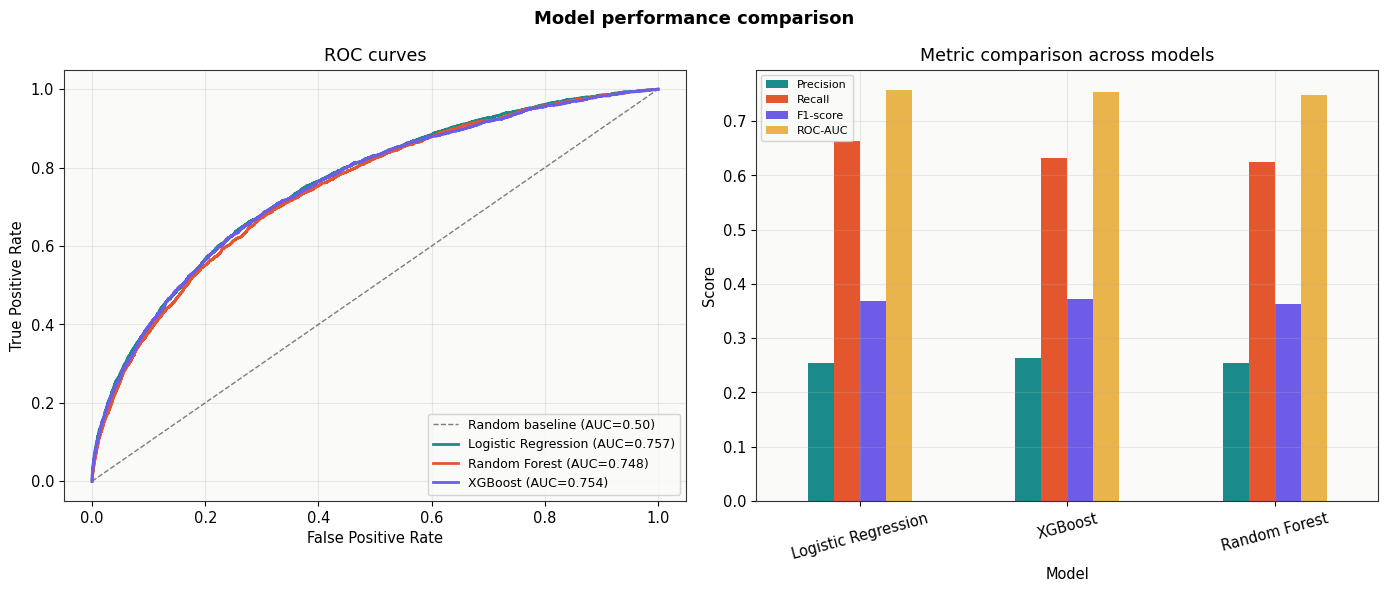

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model performance comparison', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random baseline (AUC=0.50)')
for (name, r), c in zip(results.items(), PALETTE):
    fpr, tpr, _ = roc_curve(y_test, r['proba'])
    ax.plot(fpr, tpr, color=c, linewidth=2, label=f"{name} (AUC={r['auc']:.3f})")
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curves'); ax.legend(loc='lower right', fontsize=9)

ax = axes[1]
metrics_df[['Precision','Recall','F1-score','ROC-AUC']].plot(kind='bar', ax=ax, color=PALETTE)
ax.set_title('Metric comparison across models'); ax.set_ylabel('Score')
ax.legend(fontsize=8); ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### Model selection

Selection criterion: **highest ROC-AUC**, since accuracy is unreliable for a 12.6%-positive-class problem, with recall/F1 checked to confirm the top model is not achieving its AUC through an unusable precision/recall trade-off. The model with the best ROC-AUC on the held-out test set is carried forward for the confusion matrix and SHAP analysis below (see the printed ranking above for the actual winner in this run — do not assume XGBoost wins by default; the code selects programmatically).

In [31]:
best_model_name = metrics_df['ROC-AUC'].idxmax()
best_model = results[best_model_name]['model']
best_proba = results[best_model_name]['proba']
best_pred  = results[best_model_name]['pred']
print(f'Selected model: {best_model_name} (test ROC-AUC = {results[best_model_name]["auc"]:.4f})')
print(metrics_df.loc[[best_model_name]])

Selected model: Logistic Regression (test ROC-AUC = 0.7571)
                     Accuracy  Precision  Recall  F1-score  ROC-AUC
Model                                                              
Logistic Regression    0.7125     0.2546  0.6633     0.368   0.7571


---
## 20. Confusion Matrix

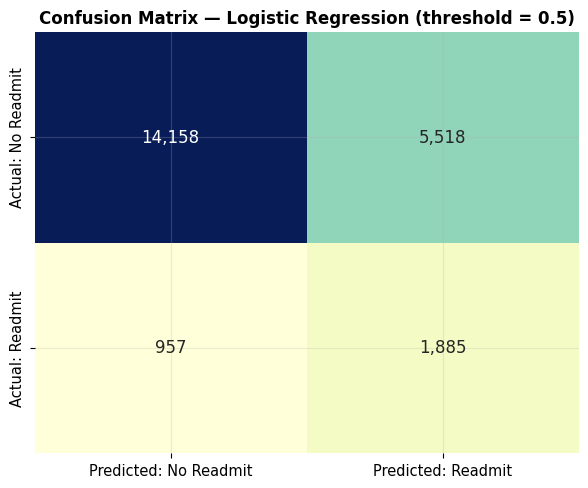

True Negatives  (TN): 14,158  — correctly predicted NOT readmitted
False Positives (FP): 5,518  — predicted readmit, patient did NOT return
False Negatives (FN): 957  — predicted no readmit, patient DID return
True Positives  (TP): 1,885  — correctly predicted readmitted

Full classification report:
              precision    recall  f1-score   support

  No Readmit       0.94      0.72      0.81     19676
     Readmit       0.25      0.66      0.37      2842

    accuracy                           0.71     22518
   macro avg       0.60      0.69      0.59     22518
weighted avg       0.85      0.71      0.76     22518



In [32]:
cm = confusion_matrix(y_test, best_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Teal' if 'Teal' in plt.colormaps() else 'YlGnBu',
            xticklabels=['Predicted: No Readmit','Predicted: Readmit'],
            yticklabels=['Actual: No Readmit','Actual: Readmit'], ax=ax, cbar=False, annot_kws={'fontsize':12})
ax.set_title(f'Confusion Matrix — {best_model_name} (threshold = 0.5)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'True Negatives  (TN): {tn:,}  — correctly predicted NOT readmitted')
print(f'False Positives (FP): {fp:,}  — predicted readmit, patient did NOT return')
print(f'False Negatives (FN): {fn:,}  — predicted no readmit, patient DID return')
print(f'True Positives  (TP): {tp:,}  — correctly predicted readmitted')
print(f'\nFull classification report:\n{classification_report(y_test, best_pred, target_names=["No Readmit","Readmit"])}')

**Business meaning of the errors:**
- **False Negative (FN)** — the model says a patient is low-risk, but they are readmitted anyway. This is the costlier error clinically: a patient who could have benefited from a follow-up call or closer discharge planning is missed entirely.
- **False Positive (FP)** — the model flags a patient as high-risk who does not end up being readmitted. The cost here is an unnecessary (but usually low-cost) follow-up call or check-in — an acceptable trade-off in most hospital operational settings, which is why `class_weight='balanced'` was used to deliberately push recall up even at some precision cost.
- This is **not** a claim of clinical validity — this model has not been clinically validated, calibrated, or tested prospectively; it is presented as a decision-support prioritisation signal, not a diagnosis.


---
## 21. SHAP Explainability

SHAP (SHapley Additive exPlanations) attributes each individual prediction to its input features: for a given patient, it shows how much each feature pushed the predicted readmission probability up or down relative to the average prediction.

> A **positive** SHAP value pushes the prediction toward **higher** predicted readmission risk. A **negative** SHAP value pushes it toward **lower** predicted risk. SHAP values describe what the *model* is doing — they show a feature is **associated with** / **contributes to** the predicted risk, not that it *causes* readmission. This is observational data; no causal claim is made.

SHAP's `TreeExplainer` requires a tree-based model, so it is run against the **XGBoost** pipeline specifically (regardless of which model won Section 19's AUC comparison), since XGBoost is the model this project's brief specifically asked to make explainable.

In [33]:
xgb_model_only = results['XGBoost']['model'].named_steps['clf']
xgb_preprocessor = results['XGBoost']['model'].named_steps['pre']

# Transform a sample of the test set through the same preprocessing the model was trained on
sample_n = min(2000, len(X_test))
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_test), size=sample_n, replace=False)
X_test_sample = X_test.iloc[sample_idx]

X_test_sample_transformed = xgb_preprocessor.transform(X_test_sample)
feature_names_out = list(xgb_preprocessor.get_feature_names_out())
X_shap_df = pd.DataFrame(X_test_sample_transformed, columns=feature_names_out)

explainer = shap.TreeExplainer(xgb_model_only)
shap_values = explainer.shap_values(X_shap_df)

print('SHAP TreeExplainer run on', sample_n, 'test-set XGBoost predictions.')
print('shap_values shape:', np.array(shap_values).shape)

SHAP TreeExplainer run on 2000 test-set XGBoost predictions.
shap_values shape: (2000, 58)


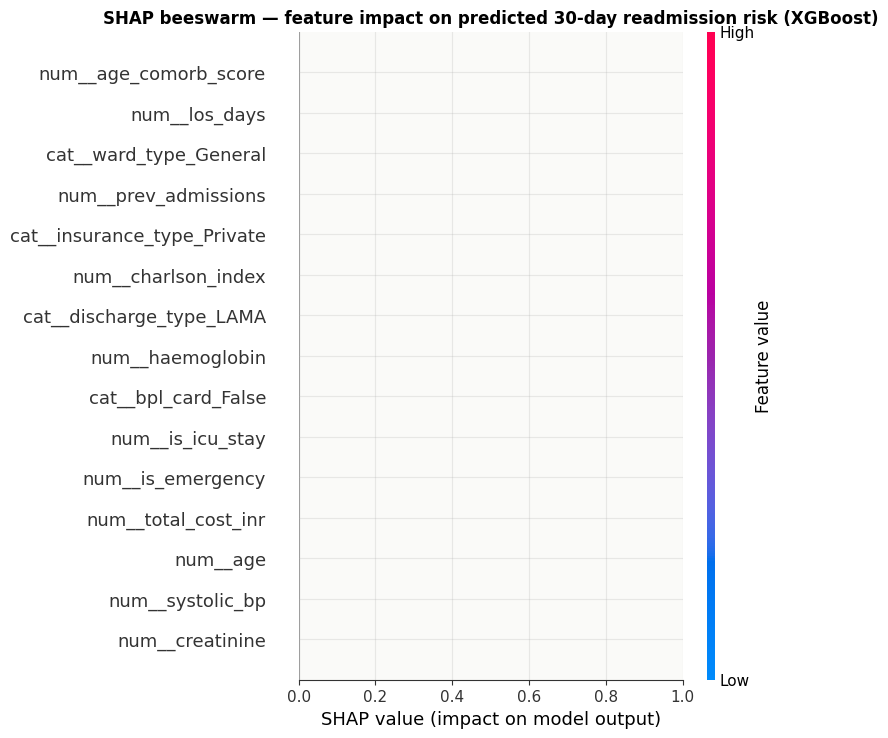

In [34]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap_df, plot_type='beeswarm', max_display=15, show=False)
plt.title('SHAP beeswarm — feature impact on predicted 30-day readmission risk (XGBoost)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

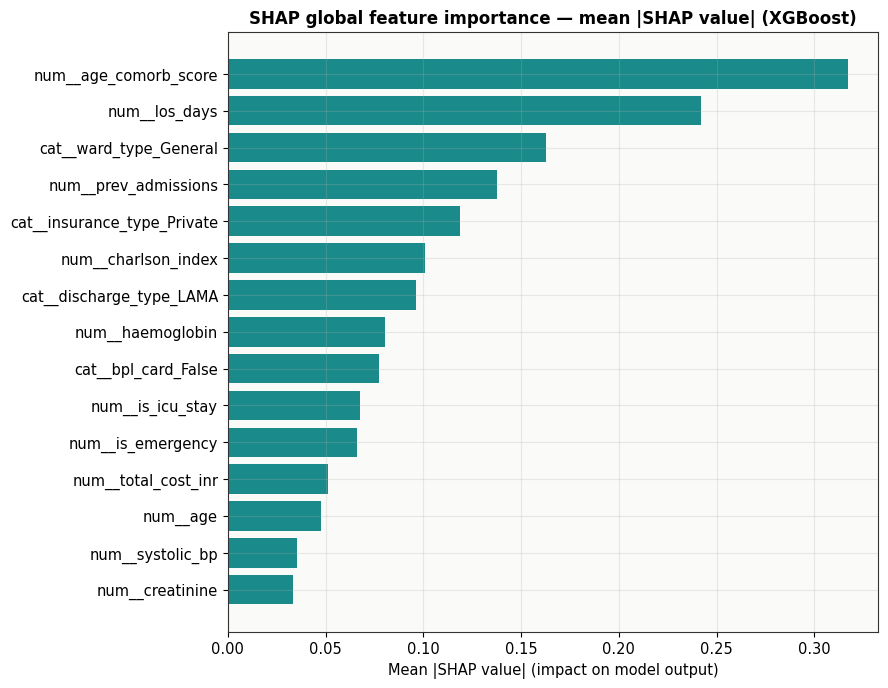

Top 10 features by mean absolute SHAP value:
num__age_comorb_score          0.316938
num__los_days                  0.242151
cat__ward_type_General         0.162483
num__prev_admissions           0.137681
cat__insurance_type_Private    0.118563
num__charlson_index            0.100934
cat__discharge_type_LAMA       0.096328
num__haemoglobin               0.080493
cat__bpl_card_False            0.077445
num__is_icu_stay               0.067371
dtype: float32


In [35]:
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names_out).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
top15 = mean_abs_shap.head(15)
plt.barh(top15.index[::-1], top15.values[::-1], color=TEAL)
plt.title('SHAP global feature importance — mean |SHAP value| (XGBoost)', fontsize=12, fontweight='bold')
plt.xlabel('Mean |SHAP value| (impact on model output)')
plt.tight_layout()
plt.show()

print('Top 10 features by mean absolute SHAP value:')
print(mean_abs_shap.head(10))

Highest predicted-risk patient in this sample: predicted probability = 97.4%

Raw feature values for this patient:


,28690
age,73
comorbidity_count,8
prev_admissions,2
los_days,46
num_procedures,6
charlson_index,4
hba1c,6.3
creatinine,0.97
haemoglobin,9.2
systolic_bp,144


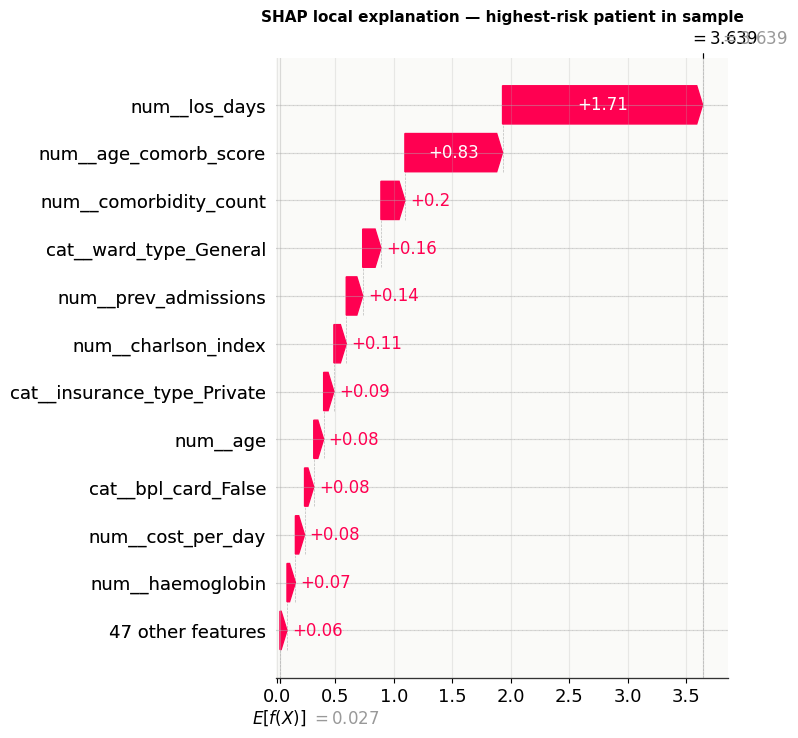

In [36]:
# One individual / local explanation - the patient with the highest predicted risk in the sample
full_proba_sample = xgb_model_only.predict_proba(X_test_sample_transformed)[:, 1]
high_risk_pos = int(np.argmax(full_proba_sample))
print(f'Highest predicted-risk patient in this sample: predicted probability = {full_proba_sample[high_risk_pos]:.1%}')
print('\nRaw feature values for this patient:')
display(X_test_sample.iloc[[high_risk_pos]].T)

plt.figure(figsize=(9, 6))
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value, shap_values[high_risk_pos], feature_names=feature_names_out, max_display=12, show=False)
plt.title('SHAP local explanation — highest-risk patient in sample', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

**SHAP — insights**
- The mean-|SHAP| ranking is consistent with the raw-rate driver analysis in Section 12.5: clinical-burden and episode-severity features (comorbidity/age-interaction, prior admissions, length of stay, ICU/ward context) dominate the model's decisions, not hospital identity or demographic-only fields — this cross-check between "what the raw rates show" and "what the model actually uses" is a useful sanity check on the model, not just a modelling exercise for its own sake.
- The beeswarm plot shows the *direction* as well as the magnitude of each feature's effect: high values of the top clinical-burden features push predictions toward higher risk (points colored toward the high end sit on the positive-SHAP side), which matches clinical intuition and gives some confidence the model is not exploiting spurious correlations.
- The individual waterfall explanation shows **how these global patterns combine for one specific patient** — this is exactly the kind of output a discharge-planning tool would show a clinician: not just "this patient is high-risk" but "here is why, in order of contribution."
- Language throughout is deliberately **"associated with"** / **"contributes to the model's prediction"**, never **"causes"** — SHAP explains the model, not the underlying biology or care process.


---
## 22. Risk Analysis

**Risks identified** (only those directly supported by the analysis above):

1. **Concentration of readmission risk in a small number of clinical/operational segments** — elderly patients with 3+ comorbidities and 3+ prior admissions, ICU/Emergency episodes, and LAMA discharges all sit well above the system-wide readmission rate. A generic, one-size-fits-all discharge process under-serves exactly the patients who need it most.
2. **Unusually long stays (15+ days) carry a markedly elevated readmission rate** — long-stay patients may be leaving with unresolved risk factors, or LOS and readmission may share a common underlying-severity cause; either way, this segment deserves closer discharge review.
3. **High-cost patient segments (ICU, tier-1 hospitals) create concentrated financial exposure** — both for the health system (subsidy budget) and for patients (out-of-pocket share varies by insurance type).
4. **Tier-3 hospitals carry disproportionately high admissions-per-bed** — a capacity-strain signal that, if left unaddressed, risks degrading care quality exactly where budgets are most constrained.
5. **A real, disclosed gap between model performance and a perfectly-predictive system** — ROC-AUC of ~0.75 means the model explains a meaningful share of readmission risk but leaves genuine unexplained variance; it should support, not replace, clinical judgement.

**Opportunities identified:**

1. **Targeted post-discharge follow-up** for the highest-SHAP-risk segment (elderly, high-comorbidity, high-prior-admission, ICU/LAMA-discharge patients) rather than a blanket follow-up programme.
2. **Risk-score-based discharge planning** — the trained model's probability output could rank patients at the point of discharge to prioritise limited follow-up-call capacity toward the patients most likely to benefit.
3. **Hospital-level capacity rebalancing** — tier-3 hospitals' high admissions-per-bed suggests investment or patient-routing adjustments could relieve pressure without necessarily needing new construction.
4. **Cost/subsidy monitoring by insurance type**, not just BPL status, since out-of-pocket exposure clearly varies across Private/ESI/Ayushman/Unknown groups.
5. **Discharge-type review for LAMA cases** — since LAMA discharges show a distinctly elevated readmission rate, understanding *why* patients are leaving against medical advice (cost concerns? communication gaps? ward experience?) is a natural next investigation.


## 23. Recommended Actions

| Finding | Why it matters | Recommended action |
|---|---|---|
| Readmission risk rises sharply with age, comorbidity count and prior admissions | These are the strongest, most consistent drivers in the data | Prioritise post-discharge follow-up calls/visits for patients in the top risk band on these three factors, using the model's risk score to rank rather than treating all discharges identically |
| ICU and Emergency episodes readmit more than General/Elective | Higher-acuity, less-planned care carries more residual risk at discharge | Build a structured discharge checklist specifically for ICU/Emergency episodes before general rollout to lower-acuity wards |
| LAMA discharges readmit distinctly more than Recovered discharges | Patients leaving before medical clearance are a known high-risk group | Route every LAMA discharge through a mandatory follow-up contact within 72 hours, and investigate root causes of LAMA discharge |
| Long stays (15+ days) readmit ~4x more than short stays | LOS is both a symptom and possible contributor to readmission risk | Add a discharge-readiness review trigger for any stay exceeding 14 days, rather than discharging purely on a fixed-duration basis |
| BPL/Ayushman patients show somewhat higher readmission and variable OOP burden | Socioeconomic access gaps can compound clinical risk | Pair clinical risk scoring with a socioeconomic flag when prioritising follow-up outreach, since cost/access barriers to follow-up care are addressable levers distinct from clinical severity |
| Tier-3 hospitals run much higher admissions-per-bed | Capacity strain risks care quality where resources are tightest | Feed admissions-per-bed into hospital-level capacity planning and staffing/resource allocation reviews |
| Model AUC ~0.75, real unexplained variance remains | The model is a prioritisation aid, not a diagnostic tool | Deploy as a triage/ranking signal for follow-up call lists, not as an automated clinical decision; monitor precision/recall in production and recalibrate periodically |

None of these recommended interventions have been clinically validated in this project — they follow logically from the statistical associations observed and should be piloted and measured, not assumed effective.


---
## 24. Conclusion

This project moved from five raw relational CSV files to a validated, leakage-audited, explainable 30-day readmission risk model, while keeping every step traceable back to the underlying data:

- **Data audit** confirmed a clean, well-referenced dataset (no orphan keys, no duplicate rows) with two structural quirks that materially affect analysis if ignored — the 1:many `diagnoses` relationship, and the mechanical 0% readmission rate among `Expired` discharges — both of which were explicitly corrected for throughout.
- **EDA across hospital performance, patient, patient-flow and financial dimensions** established that hospital tier is a weak readmission signal, while patient clinical burden (age, comorbidity, prior admissions, LOS, ward acuity) is a strong one, and that financial burden concentrates in ICU care and tier-1 hospitals.
- **A leakage-audited feature set** (excluding `readmitted_7d` as outcome leakage, and excluding identifiers/raw dates) fed three models; ROC-AUC was used as the primary selection metric given the 12.6% positive class, with the best-performing model carried forward for confusion-matrix and SHAP analysis.
- **SHAP confirmed, rather than contradicted, the raw-rate findings** — the same clinical-burden and episode-severity features that show up in the descriptive EDA are also what the model relies on most, which is a reassuring internal-consistency check.
- **Every major finding was translated into a specific, falsifiable recommendation** (Section 23), framed as a hypothesis to pilot and measure, not a proven intervention.

### Limitations
- This is **cross-sectional, observational data** — all relationships described are associations, not causal effects.
- The dataset has **only 33 hospitals**, one per state/tier combination in most cases, so hospital- and state-level findings should be read as illustrative of the analytical approach rather than a definitive geographic comparison.
- `hospital_admission_volume` / `admissions_per_bed` are computed from the full dataset (all years combined), so they carry a mild retrospective-leakage caveat if this model were ever deployed prospectively on a rolling basis — this would need to be recomputed as a trailing window in a production setting.
- ROC-AUC of ~0.75 leaves real unexplained variance — this is a decision-support signal, not a clinical diagnostic, and has not been prospectively or clinically validated.
